# Breast Cancer

Breast cancer continues to be a leading global health concern, affecting a significant portion of the female population. Early detection is the most critical factor in improving survival rates, which has led to a heavy clinical reliance on advanced imaging. While mammography and MRI are standard, ultrasound imaging has emerged as a preferred diagnostic tool due to its cost-effectiveness, real-time capabilities, and superior performance in evaluating dense breast tissue where other methods may fail.

Current research in automated diagnosis using ultrasound images has yielded high-performing models—ranging from hybrid deep learning frameworks to traditional machine learning classifiers—with some studies reporting accuracies ranging from 75.6% to 99.86%.  However, these approaches were conducted independently, often focusing exclusively on either deep learning or traditional machine learning models under varying experimental conditions. As a result, a direct comparison between these methods remains challenging, particularly in determining which approach is more effective under consistent conditions.


To address this gap, this study implements and compares both traditional machine learning and deep learning models within a unified framework. Using a consistent dataset alongside an additional data source, selected models are trained and evaluated under identical preprocessing and experimental conditions. This approach enables a more systematic and fair comparison across models of varying complexity, providing clearer insight into their relative performance in breast cancer classification. Ultimately, this research explores how computational approaches can serve as reliable decision-support tools, providing a “second opinion” to assist in the prediction of breast cancer class (whether benign, malignant, or normal) based on ultrasound images of breasts.

---

# Imports and Initialization of Seed

In [1]:
import os
import random
import seaborn as sns

import pandas as pd
from pathlib import Path

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tqdm import tqdm

os.environ['PYTHONHASHSEED'] = '22'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import importlib
import model_utils
import preprocessing_utils
import evaluation_utils
importlib.reload(model_utils)
importlib.reload(preprocessing_utils)
importlib.reload(evaluation_utils)

from data_utils import (
    get_dataset_paths,
    load_busi_dataset,
    load_bus_uclm_dataset,
    merge_image_and_mask_datasets,
    )
from preprocessing_utils import (
    augment_target_class,
    summarize_augmentation,
    flatten_images,
    convert_grayscale_to_rgb,
    )
from model_utils import (
    create_random_forest,
    build_mobilenet_basic,
    build_mobilenet_improved,
    build_mobilenet_final,
    build_resnet50_basic,
    )
from evaluation_utils import (
    evaluate_sklearn_classifier,
    evaluate_keras_classifier,
    plot_training_history,
    plot_comparative_metrics_section,
    plot_data_centric_section,
    plot_random_forest_feature_importance_section,
    plot_training_loss_section,
    plot_confusion_matrices_section,
    plot_model_complexity_section,
    plot_resolution_impact_section,
    plot_precision_recall_tradeoff_section,
    plot_final_evaluation_dashboard_section,
    plot_two_phase_training_history,
    )

In [2]:
SEED = 22
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

---

# Breast Ultrasound Datasets

For this project, we will be combining two breast ultrasound datasets, BUSI and BUS-UCLM, to have more images to work with. 

In [3]:
datasets_dir, BUSI_ROOT, BUS_UCLM_ROOT = get_dataset_paths()

print('Datasets directory:', datasets_dir)
print('BUSI exists:', BUSI_ROOT.exists())
print('BUS-UCLM exists:', BUS_UCLM_ROOT.exists())

Datasets directory: c:\Users\marxa\OneDrive\Documents\GitHub\CSC713M-Breast-Cancer-Classification\Datasets
BUSI exists: True
BUS-UCLM exists: True


## BUSI Dataset

The BUSI Dataset contains a total of 780 images. Benign, malignant, and normal classes are said to contain 437, 210, and 133 images each, respectively. The ultrasound images also come with their masked versions, which we will be excluding in this project. Initially, this was the only dataset we were supposed to use; however, since there is a visible class imbalance on top of the minimal number of images for all classes, we have decided to look for another dataset.

Below, we will run through the dataset to extract the labels along with the images, and verify if the numbers correspond with the documentation.

In [4]:
df_busi_images = load_busi_dataset(BUSI_ROOT)

print(f"\n{'='*60}")
print('Dataset_BUSI Summary')
print(f"{'='*60}")
print(f"Images: {len(df_busi_images)}")
print('\nImage distribution:')
print(df_busi_images['label'].value_counts().sort_index())
print(f"{'='*60}")


Dataset_BUSI Summary
Images: 780

Image distribution:
label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


### BUSI Class Distribution Visualization

The charts below visualize BUSI class counts and percentage composition to complement the printed summary.

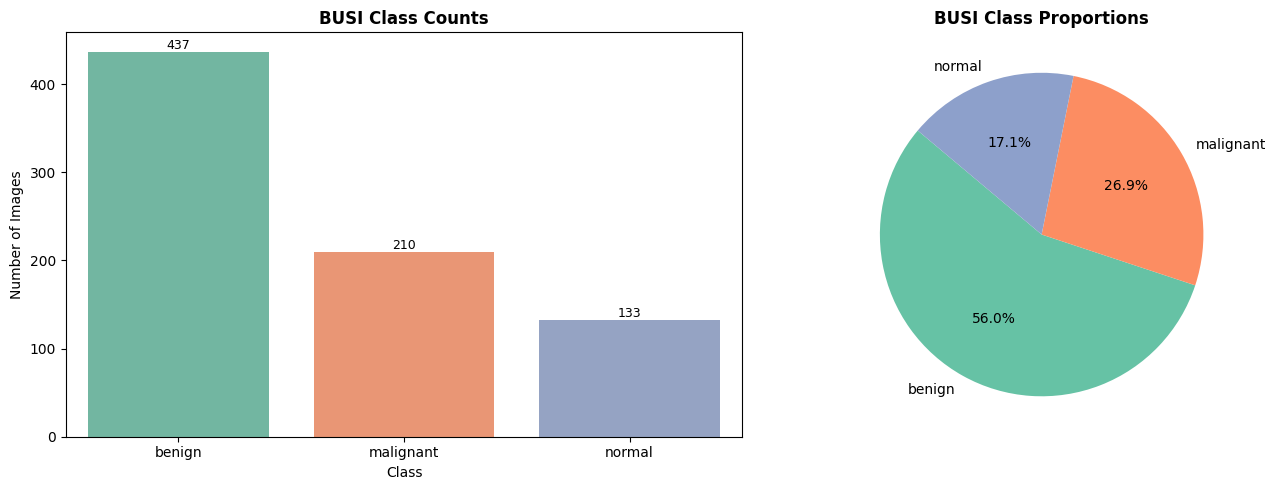

In [5]:
busi_counts = df_busi_images['label'].value_counts().sort_index()
busi_percentages = busi_counts / busi_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=busi_counts.index,
    y=busi_counts.values,
    hue=busi_counts.index,
    palette='Set2',
    legend=False,
    ax=axes[0],
    )
axes[0].set_title('BUSI Class Counts', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
for i, count in enumerate(busi_counts.values):
    axes[0].text(i, count + 3, str(count), ha='center', fontsize=9)

axes[1].pie(
    busi_percentages.values,
    labels=busi_percentages.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(busi_percentages)),
    )
axes[1].set_title('BUSI Class Proportions', fontweight='bold')

plt.tight_layout()
plt.show()

The numbers correspond to the documentation. We can proceed to the next dataset.

## BUS-UCLM Dataset

The BUS-UCLM Dataset contains a total of 683 images. Benign, malignant, and normal classes are said to contain 174, 90, and 419 images each, respectively. The ultrasound images also come with their masked versions, which we will be excluding in this project.

Below, we will run through the dataset to extract the labels along with the images, and verify if the numbers correspond with the documentation.

### Label Extraction

We will first begin by determining the label of each image. Unlike the first dataset, this dataset does not directly contain the label. Rather, the label is presented as a segmentation mask with a corresponding color. Red for malignant, green for benign, and black for normal.

In [6]:
df_bus_uclm_images = load_bus_uclm_dataset(BUS_UCLM_ROOT)

print(f"\n{'='*60}")
print('BUS-UCLM Summary')
print(f"{'='*60}")
print(f"Images with labels: {len(df_bus_uclm_images)}")
print('\nLabel distribution:')
if not df_bus_uclm_images.empty and 'label' in df_bus_uclm_images.columns:
    print(df_bus_uclm_images['label'].value_counts().sort_index())
else:
    print("No images processed or 'label' column not found.")
print(f"{'='*60}")


BUS-UCLM Summary
Images with labels: 683

Label distribution:
label
benign       174
malignant     90
normal       419
Name: count, dtype: int64


### BUS-UCLM Class Distribution Visualization

The charts below visualize BUS-UCLM class counts and percentage composition to complement the printed summary.

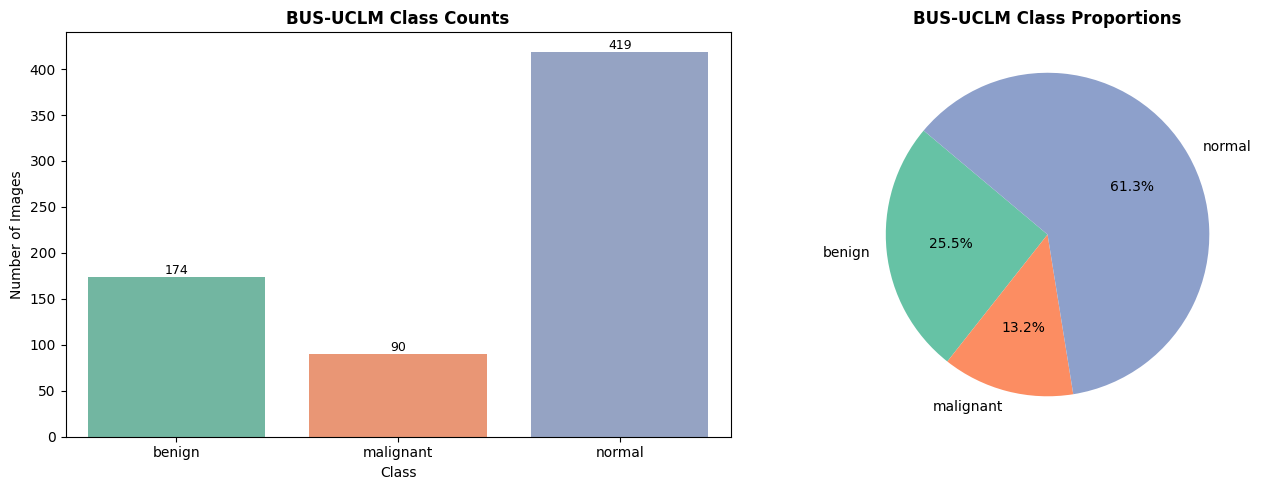

In [7]:
if not df_bus_uclm_images.empty and 'label' in df_bus_uclm_images.columns:
    bus_uclm_counts = df_bus_uclm_images['label'].value_counts().sort_index()
    bus_uclm_percentages = bus_uclm_counts / bus_uclm_counts.sum() * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(
        x=bus_uclm_counts.index,
        y=bus_uclm_counts.values,
        hue=bus_uclm_counts.index,
        palette='Set2',
        legend=False,
        ax=axes[0],
        )
    axes[0].set_title('BUS-UCLM Class Counts', fontweight='bold')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Number of Images')
    for i, count in enumerate(bus_uclm_counts.values):
        axes[0].text(i, count + 3, str(count), ha='center', fontsize=9)

    axes[1].pie(
        bus_uclm_percentages.values,
        labels=bus_uclm_percentages.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('Set2', len(bus_uclm_percentages)),
        )
    axes[1].set_title('BUS-UCLM Class Proportions', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("BUS-UCLM visualization skipped: no labeled data available.")

After matching the images with the labels, the numbers appear to correspond to the documentation. We can now merge our datasets.

## Merged Dataset

Since we have successfully extracted the images and labels from both datasets, we can now merge them. We will be working with the merged dataset for this project.

In [8]:
df_all_images = merge_image_and_mask_datasets(
    df_busi_images,
    df_bus_uclm_images,
    )

print(f"\n{'='*60}")
print('MERGED DATASET SUMMARY')
print(f"{'='*60}")
print(f"Total images: {len(df_all_images)}")
print('\nImage class distribution:')
print(df_all_images['label'].value_counts().sort_index())
print('\nPercentage distribution:')
percentage = df_all_images['label'].value_counts(normalize=True).sort_index() * 100
for label, pct in percentage.items():
    print(f"  {label.capitalize()}: {pct:.2f}%")
print(f"\n{'='*60}")
print(f"Dataset_BUSI: {len(df_busi_images)} images")
print(f"BUS-UCLM: {len(df_bus_uclm_images)} images")
print(f"{'='*60}")


MERGED DATASET SUMMARY
Total images: 1463

Image class distribution:
label
benign       611
malignant    300
normal       552
Name: count, dtype: int64

Percentage distribution:
  Benign: 41.76%
  Malignant: 20.51%
  Normal: 37.73%

Dataset_BUSI: 780 images
BUS-UCLM: 683 images


### Class Distribution Overview

To better understand class balance, we visualize both raw counts and percentage composition of benign, malignant, and normal classes.

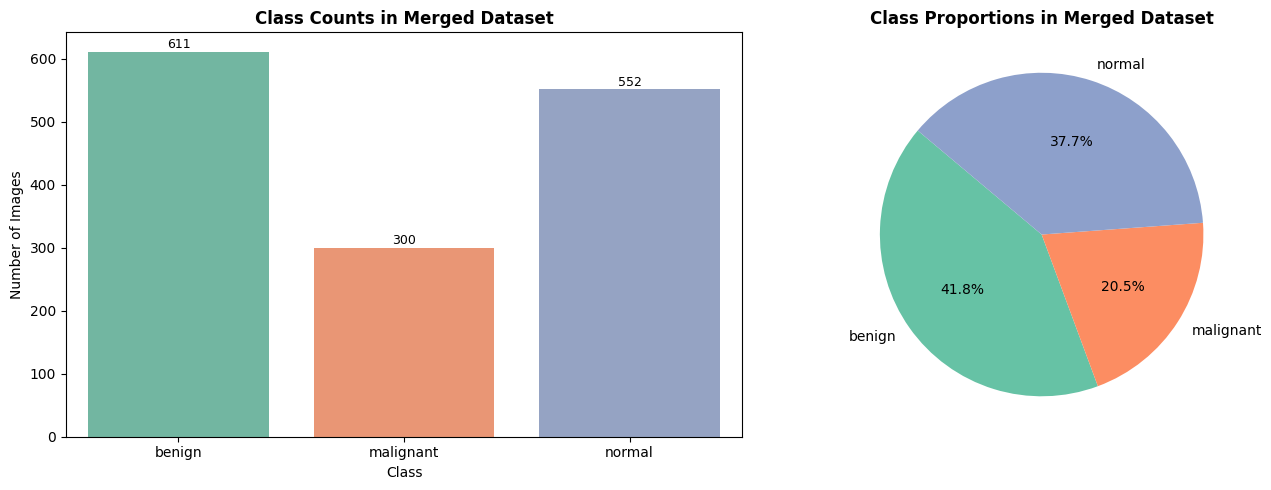

In [9]:
class_counts = df_all_images['label'].value_counts().sort_index()
class_percentages = class_counts / class_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette='Set2',
    legend=False,
    ax=axes[0],
    )
axes[0].set_title('Class Counts in Merged Dataset', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

axes[1].pie(
    class_percentages.values,
    labels=class_percentages.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(class_percentages)),
    )
axes[1].set_title('Class Proportions in Merged Dataset', fontweight='bold')

plt.tight_layout()
plt.show()

From the visualization above, we can see that there is class imbalance with 41.8% of the entire dataset being benign, and only 20.5% of the dataset is composed of malignant cases.

### Dataset Samples
Below is a visualization of selected images from each class.

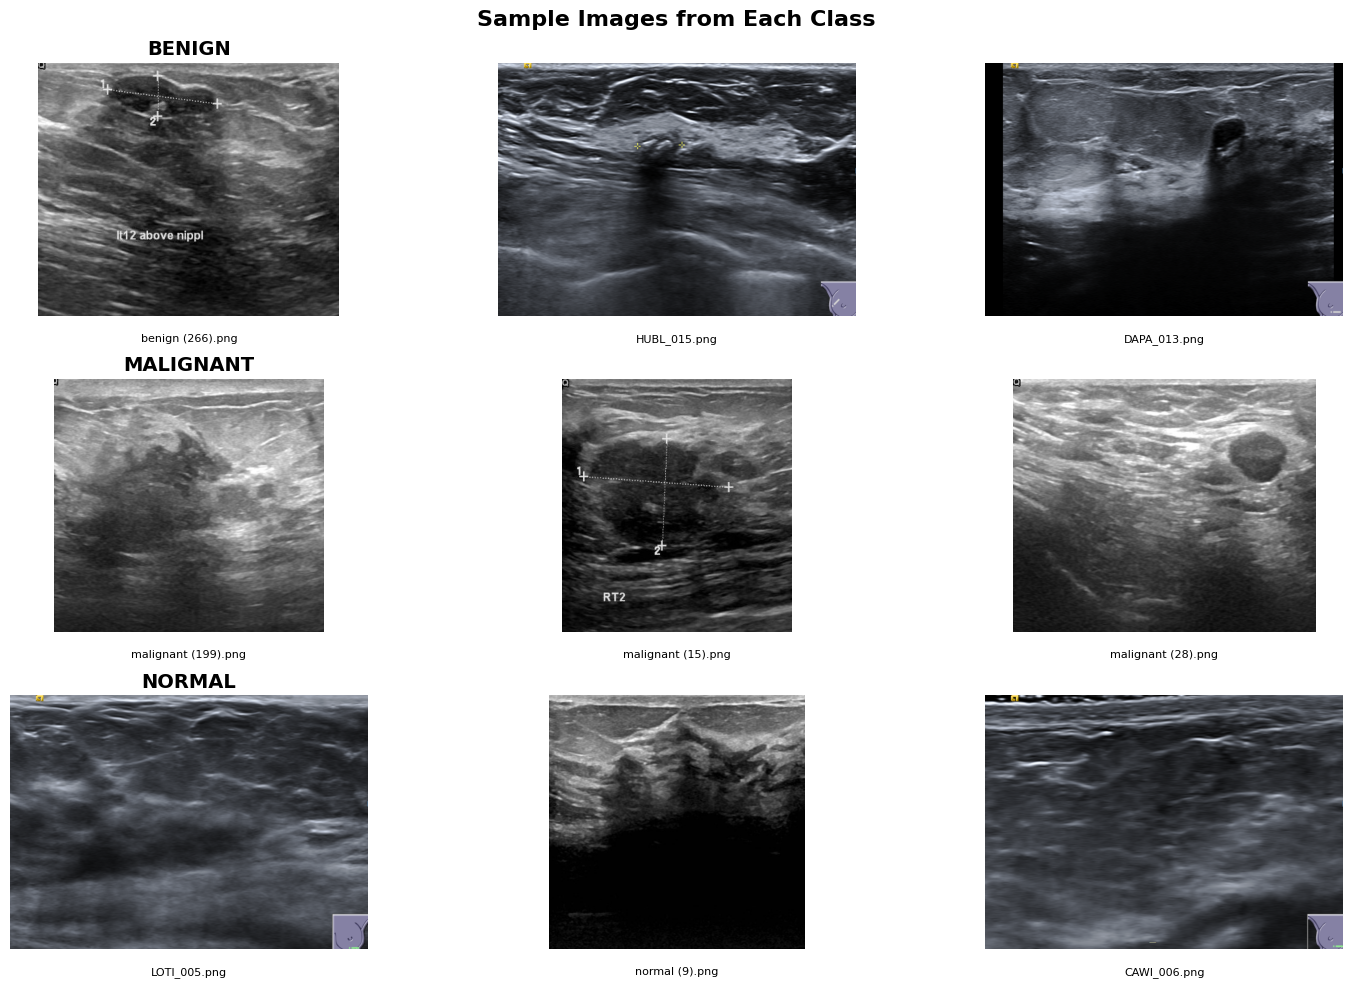

In [10]:
classes = sorted(df_all_images['label'].unique())
samples_per_class = 3
fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(15, 10))

if len(classes) == 1:
    axes = axes.reshape(1, -1)

for i, cls in enumerate(classes):
    class_samples = df_all_images[df_all_images['label'] == cls].sample(n=min(samples_per_class, len(df_all_images[df_all_images['label'] == cls])), random_state=SEED)

    for j, (idx, row) in enumerate(class_samples.iterrows()):
        img = Image.open(row['image_path'])
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')

        if j == 0:
            axes[i, j].set_title(f"{cls.upper()}", fontsize=14, fontweight='bold')

        filename = Path(row['image_path']).name
        axes[i, j].text(0.5, -0.1, filename[:20],
                      transform=axes[i, j].transAxes,
                      ha='center', fontsize=8)

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Filenames that directly indicate the label is from the BUSI Dataset, while those with 4 capital letters are from BUS-UCLM. We can also notice that, apart from grayscale markings, there are stray marks that are of another color (yellow in three cases).

### Merged Dataset Image Size Check

We analyze the scales of the images in the dataset to determine the need for rescaling.

In [86]:
size_rows = []
unreadable_paths = []

for _, row in df_all_images.iterrows():
    img = cv2.imread(row['image_path'], cv2.IMREAD_UNCHANGED)
    if img is None:
        unreadable_paths.append(row['image_path'])
        continue

    if img.ndim == 2:
        h, w = img.shape
        c = 1
    else:
        h, w, c = img.shape

    size_rows.append({
        'label': row['label'],
        'width': w,
        'height': h,
        'channels': c,
        'pixels': w * h,
        'aspect_ratio': w / h
    })

df_image_sizes = pd.DataFrame(size_rows)

print(f"Total records in df_all_images: {len(df_all_images)}")

print("\nOverall image size stats:")
print(df_image_sizes[['width', 'height', 'pixels', 'aspect_ratio']].describe().round(3))

Total records in df_all_images: 1463

Overall image size stats:
          width    height      pixels  aspect_ratio
count  1463.000  1463.000    1463.000      1463.000
mean    727.873   550.260  410448.208         1.315
std     149.408    76.524  126954.040         0.152
min     190.000   310.000   63650.000         0.567
25%     562.000   471.500  264592.500         1.196
50%     786.000   606.000  468482.000         1.413
75%     856.000   606.000  518736.000         1.413
max    1048.000   719.000  667392.000         2.053


We can see that the width and height of the images vary. This guides us to rescale the images into a uniform size before feeding them into our models. 

### Merged Dataset Image Quality Check 

We analyze brightness, contrast, and edge strength on the merged raw images to determine the need for enhancement steps.

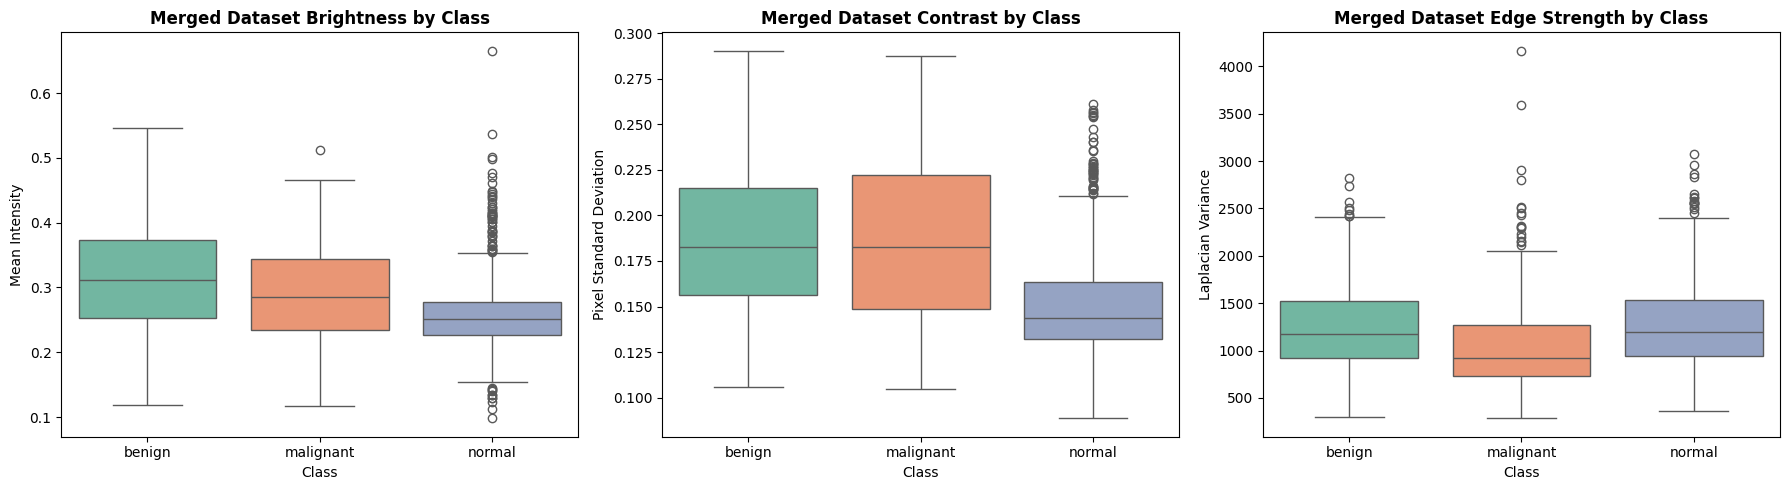

In [11]:
merged_quality_rows = []
for _, row in df_all_images.iterrows():
    img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
    merged_quality_rows.append({
        'label': row['label'],
        'mean_intensity': img.mean() / 255.0,
        'contrast_std': img.std() / 255.0,
        'edge_strength': cv2.Laplacian(img, cv2.CV_64F).var(),
    })

merged_quality_df = pd.DataFrame(merged_quality_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=merged_quality_df, x='label', y='mean_intensity', hue='label', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Merged Dataset Brightness by Class', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Mean Intensity')

sns.boxplot(data=merged_quality_df, x='label', y='contrast_std', hue='label', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Merged Dataset Contrast by Class', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Pixel Standard Deviation')

sns.boxplot(data=merged_quality_df, x='label', y='edge_strength', hue='label', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Merged Dataset Edge Strength by Class', fontweight='bold')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Laplacian Variance')

plt.tight_layout()
plt.show()

Based on the visualization, the Brightness by Class plot reveals that Benign, Malignant, and Normal tissues share nearly identical median intensities, which might make it difficult for a models to distinguish a lesion from healthy surrounding tissue based on raw grayscale values. Furthermore, the low variance in Edge Strength indicates that critical diagnostic features are buried in a low-contrast signal.

---

# Data Preprocessing

The preprocessing stage converts raw, inconsistent ultrasound scans into clean data that the models can easily interpret. First, all images are resized to 128x128 pixels to ensure a uniform input shape. This is also to support faster training. They are then converted to grayscale to remove unnecessary color data, forcing the models to focus on the textures and shapes of the tumors rather than irrelevant tints.

To improve detection, CLAHE (Contrast Limited Adaptive Histogram Equalization) is applied to sharpen the edges and internal details of the tumors. This is vital to help the models in distinguishing the borders of different cancer classes. Finally, the pixel values are normalized to a range of [0, 1] to ensure faster and more stable training. This pipeline removes background noise and highlights the most important medical features.

These are being done within one loop for efficiency in terms of time.

In [12]:
target_size = (128, 128)

images = []
labels = []

print(f"Loading and preprocessing {len(df_all_images)} images...")

# Initialize CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

for idx, row in tqdm(df_all_images.iterrows(), total=len(df_all_images)):
    try:
        img = cv2.imread(row['image_path'])

        # Convert to grayscale
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize to 128x128
        img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

        # Apply CLAHE
        img = clahe.apply(img)

        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0

        images.append(img)
        labels.append(row['label'])

    except Exception as e:
        print(f"Error processing {row['image_path']}: {e}")
        continue

X = np.array(images)
y = np.array(labels)
X = np.expand_dims(X, axis=-1)

print(f"  Image shape: {X.shape}")
print(f"  Pixel value range: [{X.min():.3f}, {X.max():.3f}]")

Loading and preprocessing 1463 images...


100%|██████████| 1463/1463 [00:19<00:00, 74.80it/s]

  Image shape: (1463, 128, 128, 1)
  Pixel value range: [0.004, 1.000]


## Visualization: Original vs. Preprocessed Images

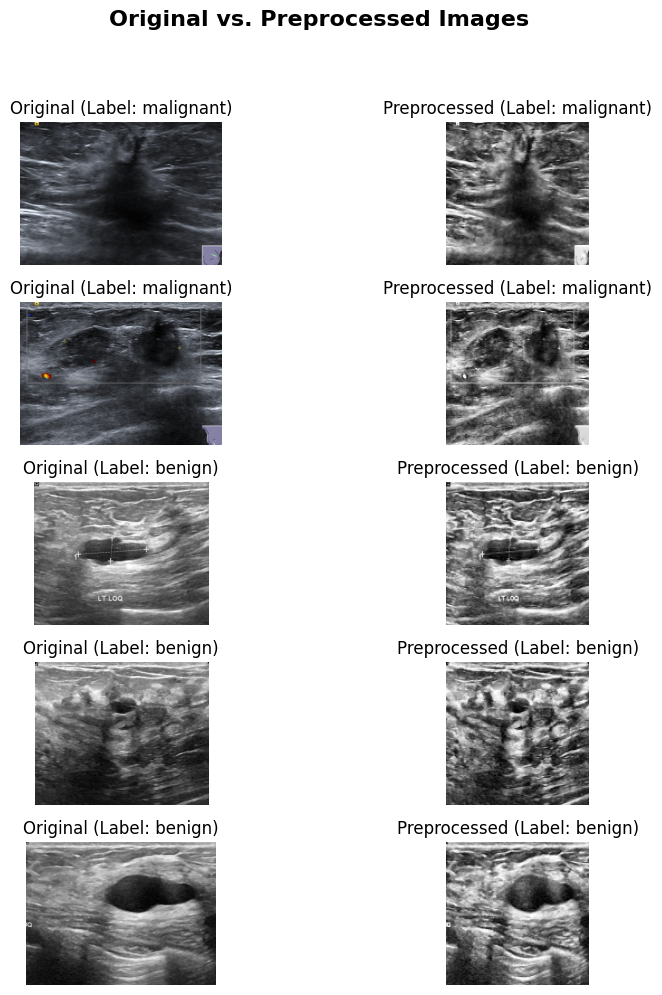

In [13]:
n_samples = 5

fig, axes = plt.subplots(n_samples, 2, figsize=(10, 2 * n_samples))
fig.suptitle('Original vs. Preprocessed Images', fontsize=16, fontweight='bold', y=1.02)

sample_indices = np.random.choice(len(df_all_images), n_samples, replace=False)

for i, original_idx in enumerate(sample_indices):
    row = df_all_images.iloc[original_idx]
    img_path = row['image_path']
    label = row['label']

    original_img_pil = Image.open(img_path).convert('RGB')
    axes[i, 0].imshow(original_img_pil)
    axes[i, 0].set_title(f"Original (Label: {label})")
    axes[i, 0].axis('off')

    preprocessed_img = X[original_idx]

    axes[i, 1].imshow(preprocessed_img[:, :, 0], cmap='gray')
    axes[i, 1].set_title(f"Preprocessed (Label: {label})")
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Comparing original images to its preprocessed version, we can note that the contrast has definitely improved and allows us much better, even with the naked eye, to determine where the tumor lies within the image.

## Image Quality Exploration

We examine brightness, contrast, and edge strength in the preprocessed images to better understand image variability and possible sources of model difficulty.

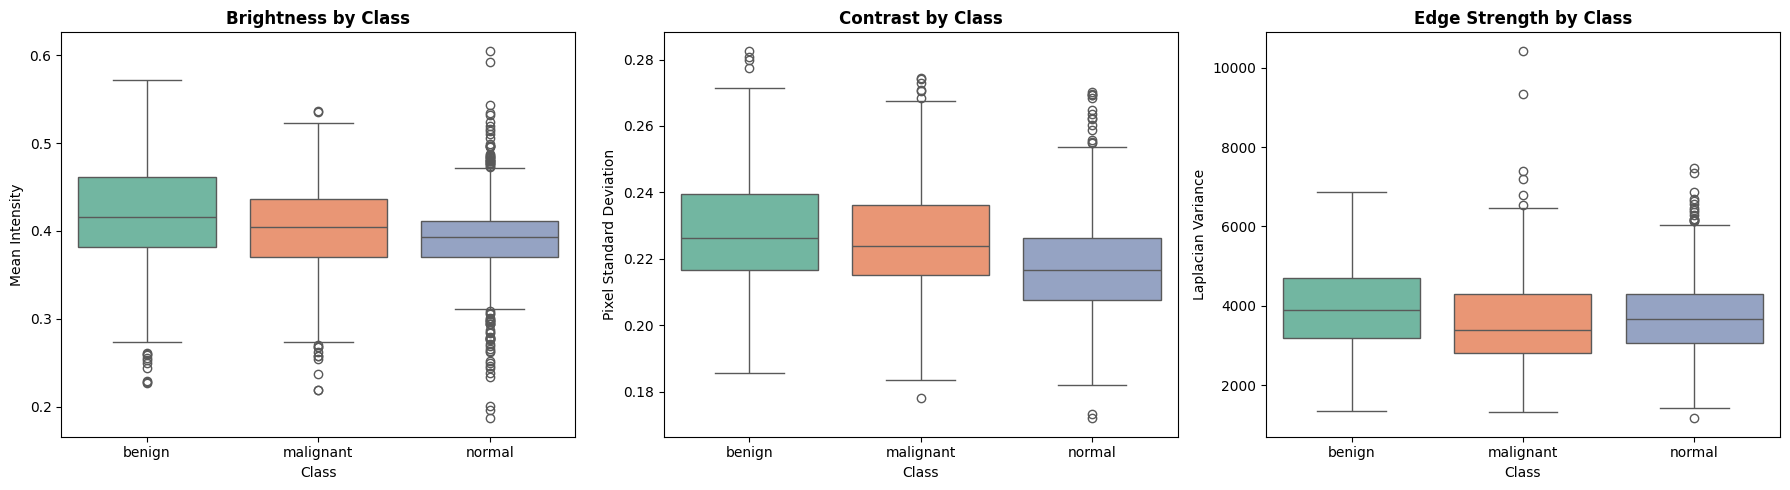

In [14]:
mean_intensity = X[:, :, :, 0].mean(axis=(1, 2))
std_intensity = X[:, :, :, 0].std(axis=(1, 2))
edge_strength = np.array([
    cv2.Laplacian((img[:, :, 0] * 255).astype(np.uint8), cv2.CV_64F).var()
    for img in X
    ])

image_quality_df = pd.DataFrame({
    'label': y,
    'mean_intensity': mean_intensity,
    'contrast_std': std_intensity,
    'edge_strength': edge_strength,
    })

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(
    data=image_quality_df,
    x='label',
    y='mean_intensity',
    hue='label',
    palette='Set2',
    legend=False,
    ax=axes[0],
    )
axes[0].set_title('Brightness by Class', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Mean Intensity')

sns.boxplot(
    data=image_quality_df,
    x='label',
    y='contrast_std',
    hue='label',
    palette='Set2',
    legend=False,
    ax=axes[1],
    )
axes[1].set_title('Contrast by Class', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Pixel Standard Deviation')

sns.boxplot(
    data=image_quality_df,
    x='label',
    y='edge_strength',
    hue='label',
    palette='Set2',
    legend=False,
    ax=axes[2],
    )
axes[2].set_title('Edge Strength by Class', fontweight='bold')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Laplacian Variance')

plt.tight_layout()
plt.show()

While CLAHE successfully improved local contrast across the dataset, the resulting boxplots show that a high degree of statistical overlap remains. Even after enhancement, the Brightness by Class medians remain tightly clustered, proving that benign and malignant lesions share nearly identical intensity profiles. This indicates that contrast improvement alone is insufficient for reliable classification, suggesting that we might need strategies such as higher resolution and Gaussian Noise regularization.

## Label Encoding



In this section, we will convert our string labels (benign, malignant, normal) into integers (0, 1, 2). While random forest does not require integer labels, MobileNetV2 and ResNet50 both require integer targets; hence, we will stick to integer label encoding for consistency.

In [15]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [16]:
print("Label Encoding Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

Label Encoding Mapping:
  benign -> 0
  malignant -> 1
  normal -> 2


---

# Data Preparation

In this section, we will be splitting our data into three: training, validation, and test. We will be following a distribution of 80-10-10. Since we have limited data, we also want each class to be distributed the same way.

In [17]:
# 80% train, 20% (10% val + 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

In [18]:
# 20% into 50% val and 50% test (each becomes 10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

Now, let us check if the dataset (and each class) has been distributed fairly among the three partitions.

In [19]:
print(f"\n{'='*60}")
print(f"Dataset Split Summary")
print(f"{'='*60}")
print(f"Training set:   {len(X_train)} images ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val)} images ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:       {len(X_test)} images ({len(X_test)/len(X)*100:.1f}%)")
print(f"{'='*60}")



Dataset Split Summary
Training set:   1170 images (80.0%)
Validation set: 146 images (10.0%)
Test set:       147 images (10.0%)


All appear to be distributed following the 80-10-10 distribution.

## Split Distribution Visualization

This plot checks whether each class remains proportionally represented across training, validation, and test sets.

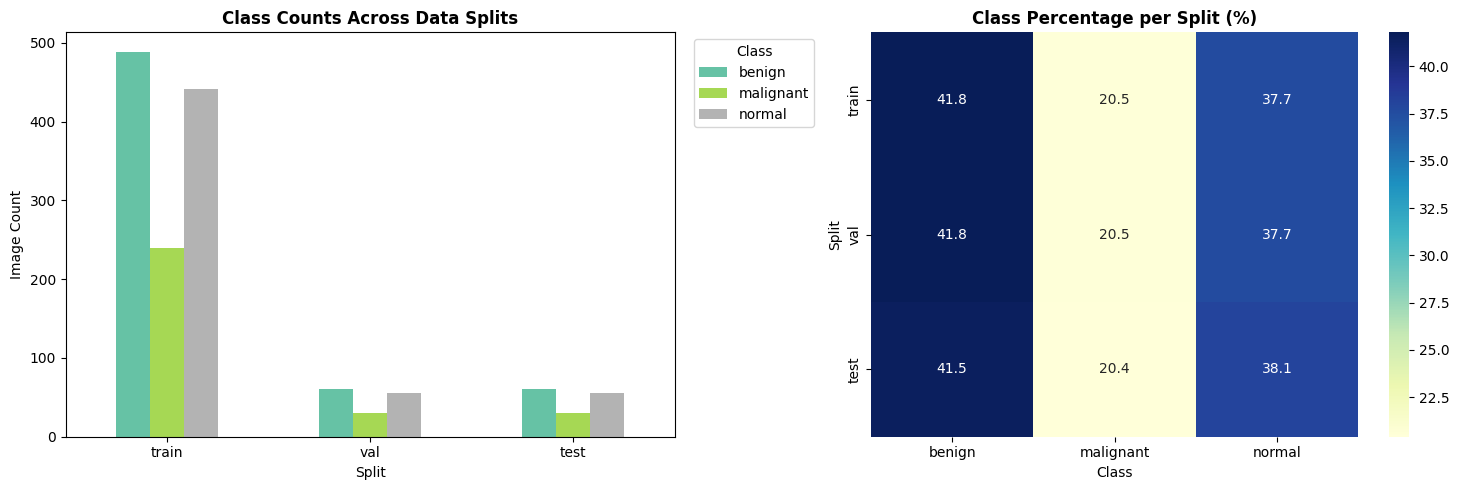

In [20]:
split_counts_df = pd.DataFrame({
    'train': pd.Series(y_train).value_counts().sort_index(),
    'val': pd.Series(y_val).value_counts().sort_index(),
    'test': pd.Series(y_test).value_counts().sort_index(),
    }).T

split_counts_df.columns = [label_encoder.classes_[i] for i in split_counts_df.columns]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

split_counts_df.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Class Counts Across Data Splits', fontweight='bold')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Image Count')
axes[0].legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

split_percent_df = split_counts_df.div(split_counts_df.sum(axis=1), axis=0) * 100
sns.heatmap(split_percent_df, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Class Percentage per Split (%)', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Split')

plt.tight_layout()
plt.show()

All appear to be distributed equally across all sets.

## Data Augmentation

Currently, our malignant class makes up only approximately 20% of our overall data. Data augmentation will be done specifically for the malignant class in the training set so the number of samples becomes closer to benign and normal classes. We will apply one augmentation per malignant image: horizontal flip.

In [21]:
# Get the integer label for 'malignant'
malignant_label = label_encoder.transform(['malignant'])[0]

print(f"Original training set size: {len(X_train)}")
print(f"Malignant samples in training: {np.sum(y_train == malignant_label)}")

Original training set size: 1170
Malignant samples in training: 240


In [22]:
target_label = malignant_label
augmentation_factor = 1
augmentation_transforms = ['flip']

X_train_augmented, y_train_augmented = augment_target_class(
    X_train,
    y_train,
    target_label,
    augmentation_factor=augmentation_factor,
    transforms=augmentation_transforms,
    rotation_angle=15,
    )

Augmenting 240 images from target class...


100%|██████████| 240/240 [00:00<00:00, 14087.85it/s]


In [23]:
summarize_augmentation(
    X_train,
    X_train_augmented,
    y_train,
    y_train_augmented,
    label_encoder,
    target_label,
    )


Augmentation Results
Training set after augmentation: 1410 images
Increase: +240 images

Class distribution after augmentation:
  benign: 489 (34.68%)
  malignant: 480 (34.04%)
  normal: 441 (31.28%)


After augmentation, the malignant class proportion increases and the training distribution becomes more balanced with each class having 31-34% representation in the dataset.

### Visualization

Below is a visualization of a subset of the malignant class. It shows the original image and its flipped version, both included in the augmented training set.

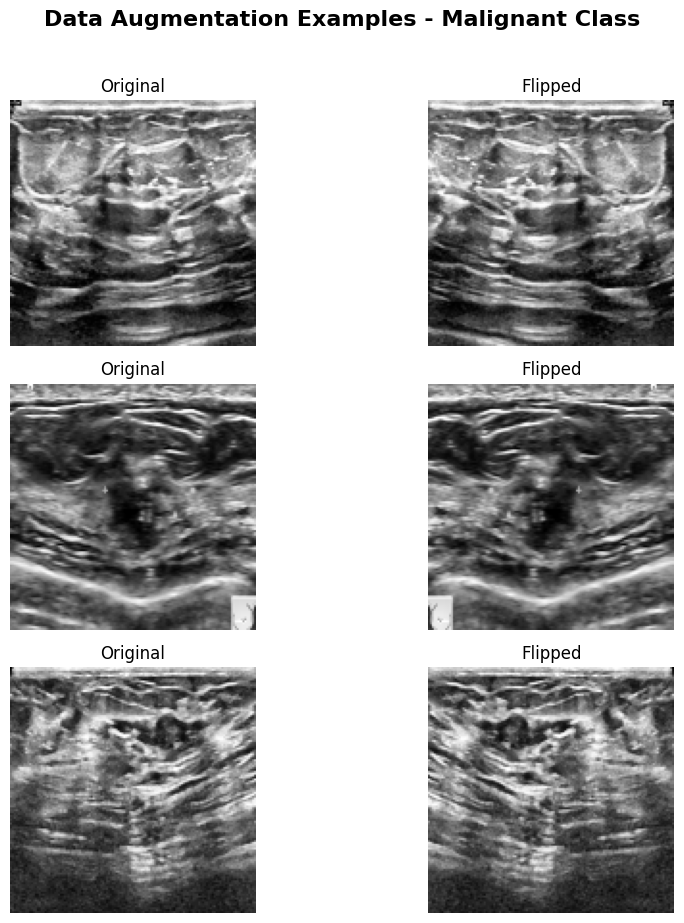

In [24]:
n_samples = 3
target_label = malignant_label
original_indices = np.where(y_train == target_label)[0][:n_samples]

fig, axes = plt.subplots(n_samples, 2, figsize=(10, 3*n_samples))

if n_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i, orig_idx in enumerate(original_indices):
    original_img = X_train[orig_idx][:, :, 0]
    flipped_img = cv2.flip(original_img, 1)

    axes[i, 0].imshow(original_img, cmap='gray')
    axes[i, 0].set_title('Original', fontsize=12)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(flipped_img, cmap='gray')
    axes[i, 1].set_title('Flipped', fontsize=12)
    axes[i, 1].axis('off')

label_name = label_encoder.classes_[target_label]
plt.suptitle(
    f'Data Augmentation Examples - {label_name.capitalize()} Class',
    fontsize=16,
    fontweight='bold',
    y=1.02,
    )
plt.tight_layout()
plt.show()

## Data Summary

In [25]:
print(f"\nDataset Shapes:")
print(f"  X_train_augmented: {X_train_augmented.shape}")
print(f"  y_train_augmented: {y_train_augmented.shape}")
print(f"  X_val:             {X_val.shape}")
print(f"  y_val:             {y_val.shape}")
print(f"  X_test:            {X_test.shape}")
print(f"  y_test:            {y_test.shape}")

print(f"\nData Properties:")
print(f"  Image size: 128x128 pixels")
print(f"  Color space: Grayscale (1 channel)")
print(f"  Pixel range: [0.0, 1.0] (normalized)")
print(f"  Data type: {X_train_augmented.dtype}")

print(f"\nLabel Encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i} = {label}")



Dataset Shapes:
  X_train_augmented: (1410, 128, 128, 1)
  y_train_augmented: (1410,)
  X_val:             (146, 128, 128, 1)
  y_val:             (146,)
  X_test:            (147, 128, 128, 1)
  y_test:            (147,)

Data Properties:
  Image size: 128x128 pixels
  Color space: Grayscale (1 channel)
  Pixel range: [0.0, 1.0] (normalized)
  Data type: float32

Label Encoding:
  0 = benign
  1 = malignant
  2 = normal


----

# Training of Models



## Random Forest

We will be using Random Forest as our first and baseline model as it is considered to be a strong non-deep-learning classifier that works well on tabularized image features. This will serve as our reference point for measuring the performance of the deep-learning models to be trained later on.

To accommodate the model’s architecture, the 2D ultrasound images will be flattened into one-dimensional feature vectors.

In [26]:
print('Flattening images for Random Forest...')
print(f"Original shape: {X_train_augmented.shape}")

X_train_flat, X_val_flat, X_test_flat = flatten_images(
    X_train_augmented,
    X_val,
    X_test,
    )

print('\nFlattened shapes:')
print(f"  X_train_flat: {X_train_flat.shape}")
print(f"  X_val_flat:   {X_val_flat.shape}")
print(f"  X_test_flat:  {X_test_flat.shape}")

Flattening images for Random Forest...
Original shape: (1410, 128, 128, 1)

Flattened shapes:
  X_train_flat: (1410, 16384)
  X_val_flat:   (146, 16384)
  X_test_flat:  (147, 16384)


### Initializing Random Forest Classifier

In [27]:
rf_model = create_random_forest(random_state=SEED)

print('\nModel Configuration:')
print('  Number of trees: 100')
print('  Class weighting: balanced')
print('  Random state: SEED')


Model Configuration:
  Number of trees: 100
  Class weighting: balanced
  Random state: SEED


### Test Set Evaluation
This section reports final performance on unseen test data using the same evaluation process across models.

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    3.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


TEST SET EVALUATION - Random Forest Baseline

Test Accuracy: 66.67%

Per-class Metrics (Precision / Recall / F1-score / Support):
              precision    recall  f1-score   support

      benign     0.7561    0.5082    0.6078        61
   malignant     0.5263    0.6667    0.5882        30
      normal     0.6912    0.8393    0.7581        56

    accuracy                         0.6667       147
   macro avg     0.6579    0.6714    0.6514       147
weighted avg     0.6845    0.6667    0.6611       147



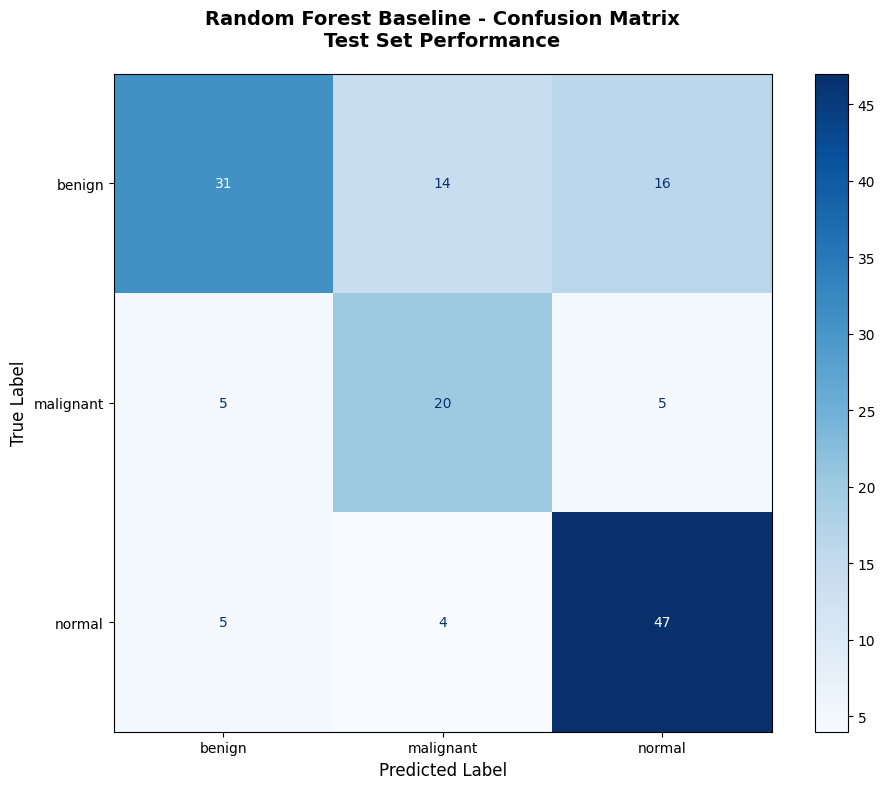

In [28]:
rf_model.fit(X_train_flat, y_train_augmented)

y_test_pred, test_accuracy, report, cm = evaluate_sklearn_classifier(
    rf_model,
    X_test_flat,
    y_test,
    label_encoder,
    title='Random Forest Baseline',
    )

The Random Forest Classifier served as a decent baseline for this project, achieving an accuracy of 66.67%. This section established the limitations of classical machine learning when applied to raw medical imagery. Since the Random Forest Classifier operates on flattened pixel vectors, it treats each pixel as an independent variable, disabling the classifier to consider the spatial relationships and geometric structures present in each image. This classifier also does not have the capacity to automatically extract features, hence why it only achieved the recorded accuracy.

The use of the Random Forest Classifier as our baseline model leads us to lean towards classification models that possess hierarchical spatial awareness rather than simple decision-tree-based analysis.

## MobileNetV2

To transition from classical machine learning to deep learning, we chose MobileNetV2 as our primary convolutional neural network (CNN) architecture. This particular model excels at extracting spatial features. Since we are working on a small dataset, we will also be utilizing a pre-trained model to allow it to recognize complex patterns within our dataset.

Apart from these, another reason that we chose this specific architecture is because it is lightweight and appropriate for clinical use.

In [29]:
print('Converting grayscale images to RGB format...')
print('Original shapes:')
print(f"  X_train_augmented: {X_train_augmented.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

X_train_rgb, X_val_rgb, X_test_rgb = convert_grayscale_to_rgb(
    X_train_augmented,
    X_val,
    X_test,
    )

print('\nConverted shapes:')
print(f"  X_train_rgb: {X_train_rgb.shape}")
print(f"  X_val_rgb: {X_val_rgb.shape}")
print(f"  X_test_rgb: {X_test_rgb.shape}")
print('\nImages converted to RGB format (3 channels)')

Converting grayscale images to RGB format...
Original shapes:
  X_train_augmented: (1410, 128, 128, 1)
  X_val: (146, 128, 128, 1)
  X_test: (147, 128, 128, 1)

Converted shapes:
  X_train_rgb: (1410, 128, 128, 3)
  X_val_rgb: (146, 128, 128, 3)
  X_test_rgb: (147, 128, 128, 3)

Images converted to RGB format (3 channels)


### Initialize MobileNetV2

This step initializes the model architecture and prepares it for compilation and training.

In [30]:
_, model = build_mobilenet_basic(
    input_shape=X_train_rgb.shape[1:],
    num_classes=len(label_encoder.classes_),
    )

This step defines the optimizer, loss, and metrics used consistently for model learning.

In [31]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Train the Model
This step trains the model on prepared data and tracks learning behavior for comparison.

In [32]:
history = model.fit(
    X_train_rgb,
    y_train_augmented,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=[],
    verbose=1
)

print(f"\nModel training completed.")

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 242ms/step - accuracy: 0.3851 - loss: 1.2306 - val_accuracy: 0.5000 - val_loss: 1.0731
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step - accuracy: 0.4801 - loss: 1.0546 - val_accuracy: 0.5548 - val_loss: 0.9696
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.5369 - loss: 0.9733 - val_accuracy: 0.6233 - val_loss: 0.9050
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - accuracy: 0.5766 - loss: 0.9152 - val_accuracy: 0.6233 - val_loss: 0.8619
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.6028 - loss: 0.8722 - val_accuracy: 0.6575 - val_loss: 0.8316
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step - accuracy: 0.6206 - loss: 0.8387 - val_accuracy: 0.6849 - val_loss: 0.8090
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - accuracy: 0.6355 - loss: 0.8114 - val_accuracy: 0.6781 - val_loss: 0.7913
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 184ms/step - accuracy: 0.6553 - loss: 0.7883 - val_accurac

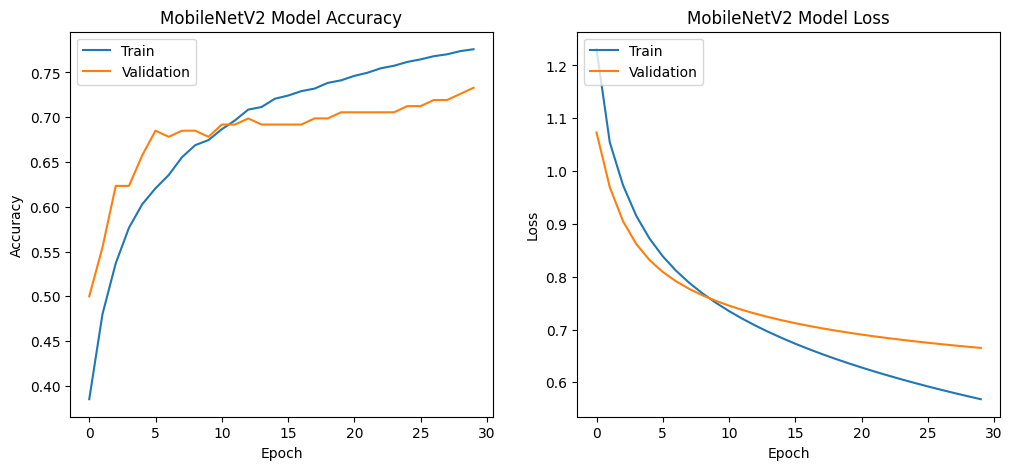

In [33]:
plot_training_history(history, 'MobileNetV2 Model')


### Test Set Evaluation
This section reports final performance on unseen test data using the same evaluation process across models.

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 436ms/step

TEST SET EVALUATION - MobileNetV2
Test Loss: 0.6907
Test Accuracy: 71.43%

Per-class Metrics (Precision / Recall / F1-score / Support):
              precision    recall  f1-score   support

      benign     0.7736    0.6721    0.7193        61
   malignant     0.6216    0.7667    0.6866        30
      normal     0.7193    0.7321    0.7257        56

    accuracy                         0.7143       147
   macro avg     0.7048    0.7236    0.7105       147
weighted avg     0.7219    0.7143    0.7150       147



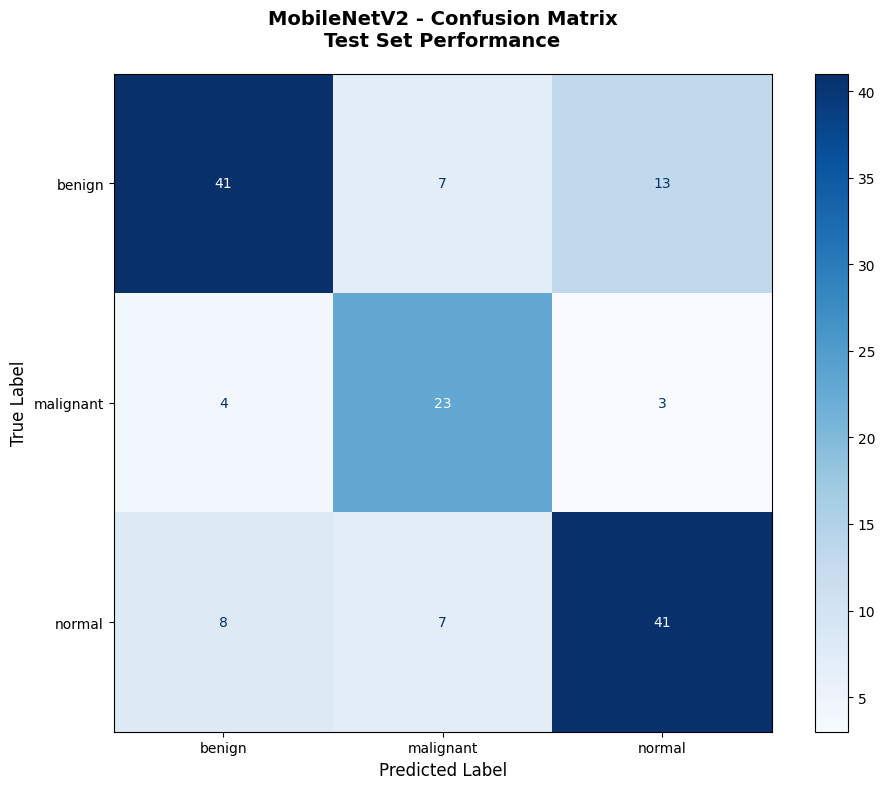

In [34]:
y_pred_mobilenet, accuracy, loss, report_mobilenet, cm_mobilenet = evaluate_keras_classifier(
    model,
    X_test_rgb,
    y_test,
    label_encoder,
    title='MobileNetV2',
    )


The MobileNetV2 was able to achieve an accuracy of 71.43%, a significant increase from that of the Random Forest Classifier. With the malignant class having 76.67% recall, it shows that using a model that has been pre-trained already enhances its sensitivity to borders, edges, or just malignant features collectively. However, the model demonstrated poor performance when identifying benign cases, where 13 cases where classified as normal. 

## MobileNetV2 2.0

To take a giant step forward from the initial model, we have implemented multiple changes that aim to force the model to focus on the tumors and learn instead of memorize. We made use of GaussianNoise to add more noise during training to allow the model to focus on the actual shape of the tumor. We added Batch Normalization layers to stabilize training and Dropout layers to sprea learning across the network. We also added class weights to give more importance to the malignant class, and integrated stronger training controls like ReduceLROnPlateau and EarlyStopping.

For this model, we also trained it in two phases. First would be training with a frozen backbone to preserve pretrained features, then training with an unfrozen backbone for the last 20 layers to extract features from our own dataset. 

### Build MobileNetV2 2.0
This step initializes the model architecture and prepares it for compilation and training.

In [35]:
import importlib
import model_utils
importlib.reload(model_utils)

tf.keras.backend.clear_session()
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

improved_base_model, improved_model = model_utils.build_mobilenet_improved(
    input_shape=X_train_rgb.shape[1:],
    num_classes=len(label_encoder.classes_),
    )


### Compile MobileNetV2 2.0 Model
This step defines the optimizer, loss, and metrics used consistently for model learning.

In [36]:
improved_model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )


### Strategies for MobileNetV2 2.0

In [37]:
improved_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    min_delta=0.0015,
    restore_best_weights=True,
    start_from_epoch=6,
    )

improved_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    cooldown=1,
    min_lr=1e-6,
    verbose=1,
    )

improved_class_weight_dict = {
    0: 1.0,  # Benign
    1: 1.25,  # Malignant
    2: 1.0,  # Normal
    }

### Train MobileNetV2 2.0
This step fits the model with callbacks and validation monitoring to improve generalization.

In [38]:
# Reset RNGs 
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

Reset seeds, then start phase 1 training with the backbone frozen.

In [39]:
# Phase 1: train classifier head with frozen backbone
improved_history = improved_model.fit(
    X_train_rgb,
    y_train_augmented,
    epochs=60,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=[improved_early_stopping, improved_reduce_lr],
    class_weight=improved_class_weight_dict,
    shuffle=True,
    verbose=1,
    )

Epoch 1/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step - accuracy: 0.3730 - loss: 1.8446 - val_accuracy: 0.4110 - val_loss: 1.1589 - learning_rate: 1.0000e-04
Epoch 2/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.5213 - loss: 1.2729 - val_accuracy: 0.5548 - val_loss: 0.8968 - learning_rate: 1.0000e-04
Epoch 3/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.5738 - loss: 1.1209 - val_accuracy: 0.6233 - val_loss: 0.7692 - learning_rate: 1.0000e-04
Epoch 4/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.6213 - loss: 0.9588 - val_accuracy: 0.6575 - val_loss: 0.7383 - learning_rate: 1.0000e-04
Epoch 5/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - accuracy: 0.6645 - loss: 0.8560 - val_accuracy: 0.6644 - val_loss: 0.7212 - learning_rate: 1.0000e-04
Epoch 6/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.6915 - loss: 0.8026 - val_accuracy: 0.6438 - val_loss: 0.7244 - learning_rate: 1.0000e-04
Epoch 7/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 177ms/step - accuracy

Unfreeze upper layers, recompile, and continue with phase 2 fine-tuning.

In [40]:
# Phase 2: fine-tune upper backbone layers
for layer in improved_base_model.layers[:-20]:
    layer.trainable = False
for layer in improved_base_model.layers[-20:]:
    layer.trainable = True

improved_model.compile(
    optimizer=Adam(learning_rate=1e-5, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )


Now, we will start fine-tuning.

In [41]:
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

improved_finetune_history = improved_model.fit(
    X_train_rgb,
    y_train_augmented,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=[improved_early_stopping, improved_reduce_lr],
    class_weight=improved_class_weight_dict,
    shuffle=True,
    verbose=1,
    )

print("\nMobileNetV2 2.0 training and fine-tuning completed.")

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 319ms/step - accuracy: 0.5766 - loss: 1.1125 - val_accuracy: 0.6986 - val_loss: 0.6372 - learning_rate: 1.0000e-05
Epoch 2/20
44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.5937 - loss: 1.0138
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 265ms/step - accuracy: 0.6092 - loss: 1.0135 - val_accuracy: 0.6986 - val_loss: 0.6520 - learning_rate: 1.0000e-05
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 228ms/step - accuracy: 0.6645 - loss: 0.8984 - val_accuracy: 0.7123 - val_loss: 0.6593 - learning_rate: 5.0000e-06
Epoch 4/20
44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6764 - loss: 0.8345
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.6809 - loss: 0.8337 - val_accuracy: 0.7192 - val_loss: 0.6683 - learning_rate: 5.0000e-06
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.6574 

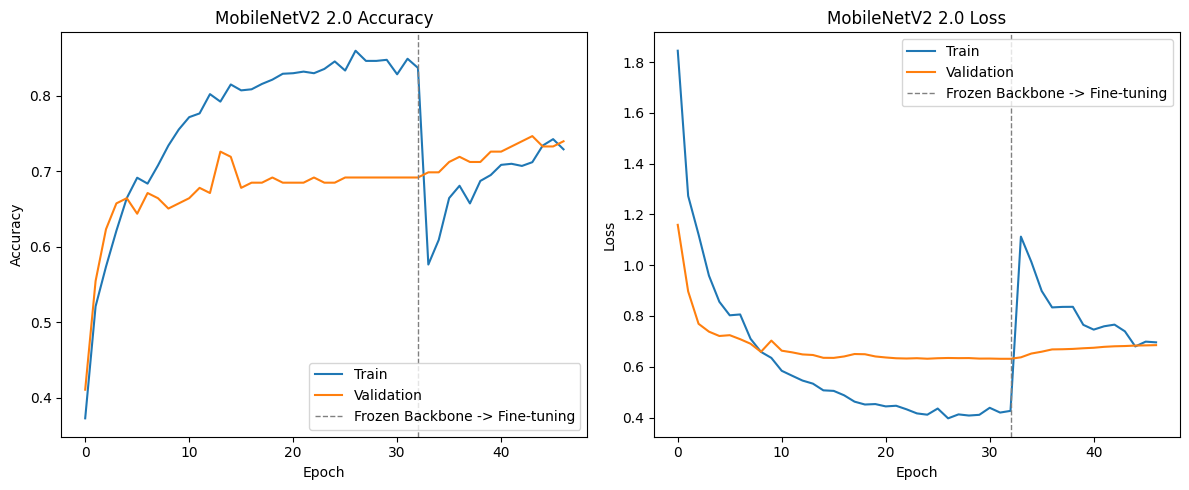

In [42]:
plot_two_phase_training_history(
    improved_history,
    improved_finetune_history,
    title='MobileNetV2 2.0',
    phase1_label='Frozen Backbone',
    phase2_label='Fine-tuning',
)

We can see from the graphs that the model was overfitting during the first phase, but then the transition to the second phase caused a sudden spike in loss and drop in accuracy, which resulted in a successful convergence where the gap between the training and validation accuracy and loss became narrow. This is because the model has started to learn the actual features from the ultrasound images instead of simply memorizing them.

### Test Set Evaluation
This section reports final performance on unseen test data using the same evaluation process across models.

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 264ms/step

TEST SET EVALUATION - MobileNetV2 2.0
Test Loss: 0.7242
Test Accuracy: 76.19%

Per-class Metrics (Precision / Recall / F1-score / Support):
              precision    recall  f1-score   support

      benign     0.8654    0.7377    0.7965        61
   malignant     0.6286    0.7333    0.6769        30
      normal     0.7500    0.8036    0.7759        56

    accuracy                         0.7619       147
   macro avg     0.7480    0.7582    0.7497       147
weighted avg     0.7731    0.7619    0.7642       147



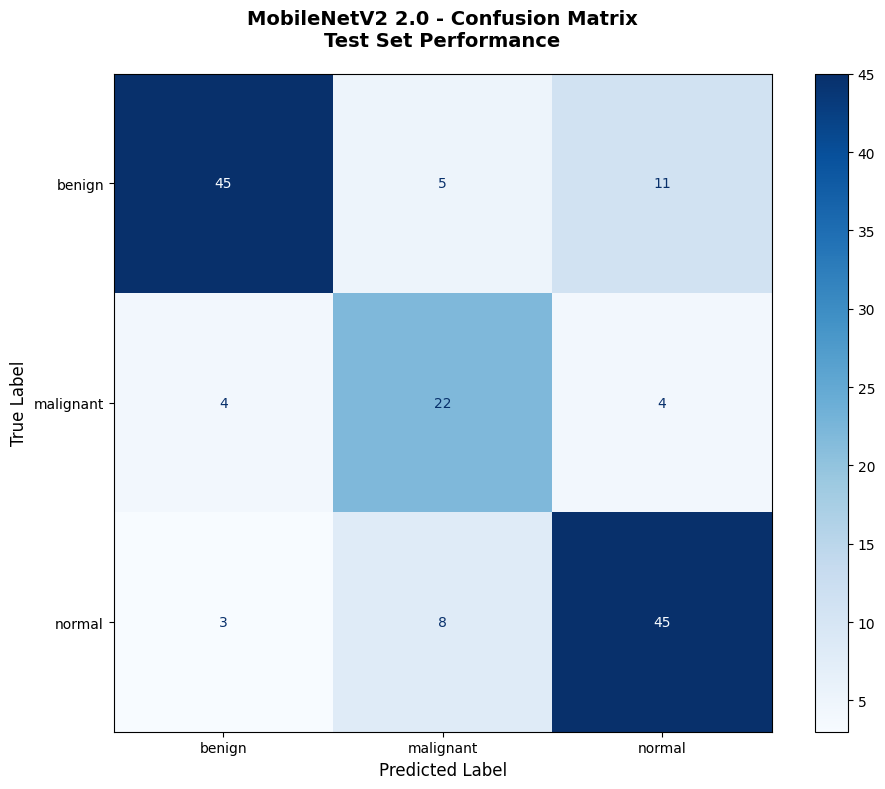

In [43]:
(
    y_pred_improved_mobilenet,
    improved_accuracy,
    improved_loss,
    report_improved_mobilenet,
    cm_improved_mobilenet,
    ) = evaluate_keras_classifier(
    improved_model,
    X_test_rgb,
    y_test,
    label_encoder,
    title='MobileNetV2 2.0',
    )


The MobileNetV2 2.0 model has significantly improved in comparison to our initial model, with the latest model achieving an accuracy of 76.19%. Another result to take note of is the recall for the malignant class which now stands at 73.33%. The improvements can be attributed to multiple factors: the added Batch Normalization layers stabilized the training process and accelerated convergence, while the Dropout layers prevented overfitting by forcing the network to learn more features across itself. Combined with the class weights we applied to prioritize malignant cases, the model achieved better discrimination between classes. However, it is still alarming that the model has flagged 15 cases to be normal when it was supposed to be either benign or malignant.


## MobileNetV2 3.0

Building on the progress of our improved MobileNetV2 2.0, we realized that while the previous model was getting better at recognizing medical textures, it might have gotten "distracted" by the heavy, grainy noise found in ultrasound images. In this new version, we decided to make the model's rules much stricter to force it to focus on what really matters. We increased the Gaussian Noise from 0.03 to 0.1 and added L2 regularization to force the model to ignore messy background. We also increased the dropout by 0.05 each.

To maximize diagnostic accuracy and clinical safety, we also increased the input resolution to 224x224 and applied heavier data augmentation specifically to malignant samples. And in training the model, we also utilized 'Restore Best Weights' to ensure that the final model used for evaluation was the most optimized version of the network, rather than simply the version from the final training epoch.

### Build MobileNetV2 3.0
This step initializes the model architecture and prepares it for compilation and training.

In [44]:
tf.keras.backend.clear_session()
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Resize to 224x224
X_train_rgb_final224 = tf.image.resize(X_train_rgb, (224, 224)).numpy().astype(np.float32)
X_val_rgb_final224 = tf.image.resize(X_val_rgb, (224, 224)).numpy().astype(np.float32)
X_test_rgb_final224 = tf.image.resize(X_test_rgb, (224, 224)).numpy().astype(np.float32)

final_base_model, final_model = model_utils.build_mobilenet_final(
    input_shape=X_train_rgb_final224.shape[1:],
    num_classes=len(label_encoder.classes_),
    )

print('Final input shapes:', X_train_rgb_final224.shape, X_val_rgb_final224.shape, X_test_rgb_final224.shape)

Final input shapes: (1410, 224, 224, 3) (146, 224, 224, 3) (147, 224, 224, 3)


### Compile MobileNetV2 3.0
This step defines the optimizer, loss, and metrics used consistently for model learning.

In [45]:
final_model.compile(
    optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )

### Strategies for MobileNetV2 3.0

Set checkpointing and callback rules before running long training.

In [46]:
Path('checkpoints').mkdir(exist_ok=True)

final_checkpoint_path = Path('checkpoints/final_best.weights.h5')
if final_checkpoint_path.exists():
    final_checkpoint_path.unlink()

final_checkpoint = ModelCheckpoint(
    filepath=str(final_checkpoint_path),
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
    )

final_early_stopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=6,
    min_delta=0.0015,
    restore_best_weights=True,
    start_from_epoch=5,
    )

final_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=2,
    cooldown=1,
    min_lr=5e-7,
    verbose=1,
    )

Create class-wise augmentation and expand the training set.

In [47]:
final_augmentation_transforms = ['flip_h', 'rotate_pos', 'flip_v', 'rotate_neg']
malignant_label = int(label_encoder.transform(['malignant'])[0])

final_X_aug_parts = []
final_y_aug_parts = []

for label_idx, class_name in enumerate(label_encoder.classes_):
    class_mask = y_train == label_idx
    X_class = X_train[class_mask]
    y_class = y_train[class_mask]

    # Apply 4x augmentation for malignant, 2x for others
    final_augmentation_factor = 4 if label_idx == malignant_label else 2

    X_class_aug, y_class_aug = augment_target_class(
        X_class,
        y_class,
        target_label=label_idx,
        augmentation_factor=final_augmentation_factor,
        transforms=final_augmentation_transforms,
        rotation_angle=12,
        )

    final_X_aug_parts.append(X_class_aug)
    final_y_aug_parts.append(y_class_aug)
    aug_info = f"(×{final_augmentation_factor})" if label_idx == malignant_label else "(×2)"
    print(f"Final-only augmentation for {class_name} {aug_info}: {len(y_class)} -> {len(y_class_aug)}")

final_X_train_augmented = np.concatenate(final_X_aug_parts, axis=0)
final_y_train_augmented = np.concatenate(final_y_aug_parts, axis=0)

Augmenting 489 images from target class...


100%|██████████| 489/489 [00:00<00:00, 5375.65it/s]


Final-only augmentation for benign (×2): 489 -> 1467
Augmenting 240 images from target class...


100%|██████████| 240/240 [00:00<00:00, 3473.00it/s]


Final-only augmentation for malignant (×4): 240 -> 1200
Augmenting 441 images from target class...


100%|██████████| 441/441 [00:00<00:00, 6966.89it/s]


Final-only augmentation for normal (×2): 441 -> 1323


In [48]:
final_shuffle_idx = np.random.default_rng(SEED).permutation(len(final_y_train_augmented))
final_X_train_augmented = final_X_train_augmented[final_shuffle_idx]
final_y_train_augmented = final_y_train_augmented[final_shuffle_idx]

Prepare RGB tensors and compute class weights for training.

In [49]:

final_X_train_rgb = np.repeat(final_X_train_augmented, 3, axis=-1)
final_X_train_rgb = tf.image.resize(final_X_train_rgb, (224, 224)).numpy().astype(np.float32)

class_counts = np.bincount(final_y_train_augmented)
final_class_weight_dict = {
    i: len(final_y_train_augmented) / (len(class_counts) * count)
    for i, count in enumerate(class_counts)
    }

final_class_weight_dict[malignant_label] *= 1.10

print('\nFinal-only augmented training size:', len(final_y_train_augmented))
print('Final class distribution:')
for label_idx, class_name in enumerate(label_encoder.classes_):
    count = np.sum(final_y_train_augmented == label_idx)
    pct = 100.0 * count / len(final_y_train_augmented)
    print(f"  {class_name}: {count} ({pct:.1f}%)")
print('Final class weights:', final_class_weight_dict)






Final-only augmented training size: 3990
Final class distribution:
  benign: 1467 (36.8%)
  malignant: 1200 (30.1%)
  normal: 1323 (33.2%)
Final class weights: {0: np.float64(0.9066121336059987), 1: np.float64(1.2191666666666667), 2: np.float64(1.0052910052910053)}


In [50]:
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

Train phase 1 with frozen backbone, then switch to phase 2 settings.

### Train MobileNetV2 3.0
This step fits the model with callbacks and validation monitoring to improve generalization.

In [51]:
final_history = final_model.fit(
    final_X_train_rgb,
    final_y_train_augmented,
    validation_data=(X_val_rgb_final224, y_val),
    epochs=100,
    batch_size=32,
    class_weight=final_class_weight_dict,
    callbacks=[final_checkpoint, final_early_stopping, final_reduce_lr],
    shuffle=True,
    verbose=1,
    )

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.3712 - loss: 1.7616
Epoch 1: val_loss improved from None to 0.99109, saving model to checkpoints\final_best.weights.h5

Epoch 1: finished saving model to checkpoints\final_best.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 129s 786ms/step - accuracy: 0.4065 - loss: 1.6334 - val_accuracy: 0.5548 - val_loss: 0.9911 - learning_rate: 5.0000e-05
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.4551 - loss: 1.4728
Epoch 2: val_loss improved from 0.99109 to 0.92760, saving model to checkpoints\final_best.weights.h5

Epoch 2: finished saving model to checkpoints\final_best.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 461ms/step - accuracy: 0.4865 - loss: 1.3810 - val_accuracy: 0.6370 - val_loss: 0.9276 - learning_rate: 5.0000e-05
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.5307 - loss: 1.2616
Epoch 3: val_loss improved from 0.92760 to 0.84907, saving model to checkpoints\final_best.weight

In [52]:
for layer in final_base_model.layers[:-30]:
    layer.trainable = False

for layer in final_base_model.layers[-30:]:
    layer.trainable = True

for layer in final_base_model.layers:
    if layer.__class__.__name__ == 'BatchNormalization':
        layer.trainable = False

In [53]:
final_model.compile(
    optimizer=Adam(learning_rate=5e-6, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )

In [54]:
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [55]:
final_finetune_history = final_model.fit(
    final_X_train_rgb,
    final_y_train_augmented,
    validation_data=(X_val_rgb_final224, y_val),
    initial_epoch=len(final_history.history['loss']),
    epochs=100,
    batch_size=32,
    class_weight=final_class_weight_dict,
    callbacks=[final_checkpoint, final_early_stopping, final_reduce_lr],
    shuffle=True,
    verbose=1,
    )

if final_checkpoint_path.exists():
    final_model.load_weights(str(final_checkpoint_path))

print('\nFinal optimized MobileNetV2 trained.')

Epoch 31/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.7434 - loss: 0.6948
Epoch 31: val_loss improved from 0.67063 to 0.66437, saving model to checkpoints\final_best.weights.h5

Epoch 31: finished saving model to checkpoints\final_best.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 99s 633ms/step - accuracy: 0.7406 - loss: 0.7021 - val_accuracy: 0.7397 - val_loss: 0.6644 - learning_rate: 5.0000e-06
Epoch 32/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.7507 - loss: 0.7011
Epoch 32: val_loss improved from 0.66437 to 0.62896, saving model to checkpoints\final_best.weights.h5

Epoch 32: finished saving model to checkpoints\final_best.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 72s 576ms/step - accuracy: 0.7574 - loss: 0.6815 - val_accuracy: 0.7534 - val_loss: 0.6290 - learning_rate: 5.0000e-06
Epoch 33/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.7551 - loss: 0.6787
Epoch 33: val_loss improved from 0.62896 to 0.61092, saving model to checkpoints\final_b

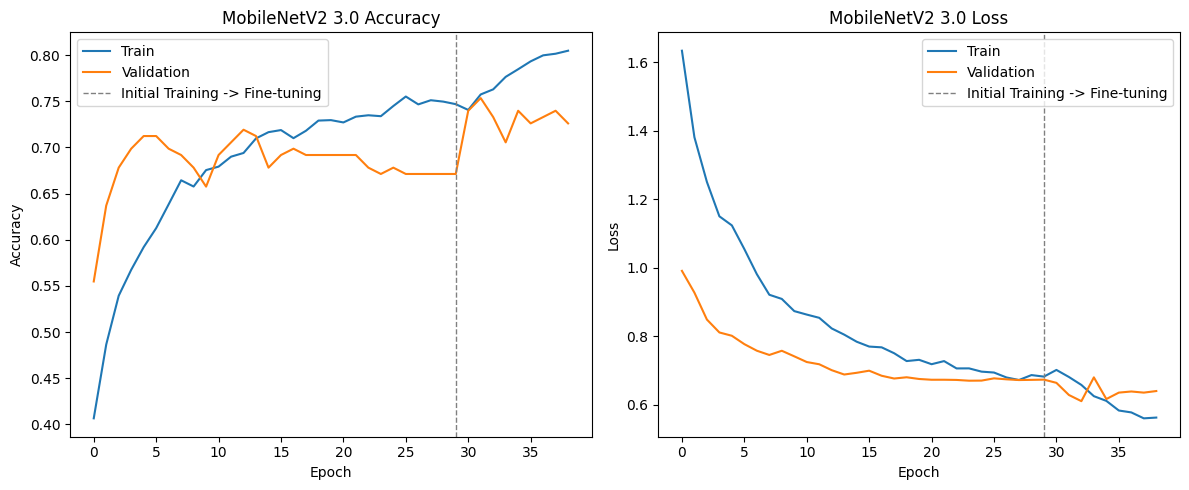

In [56]:
plot_two_phase_training_history(
    final_history,
    final_finetune_history,
    title='MobileNetV2 3.0',
    phase1_label='Initial Training',
    phase2_label='Fine-tuning',
)

Unlike in MobileNetV2 2.0, this model did not have much changes during the transition from phase 1 to phase 2. The model also converged successfully, leaving only a narrow gap between the training and validation accuracy and loss. This might be because of the added Gaussian Noise and dropout, which prevented any case of overfitting.

### Test Set Evaluation
This section reports final performance on unseen test data using the same evaluation process across models.

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001814387DDA0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 523ms/step

TEST SET EVALUATION - MobileNetV2 3.0
Test Loss: 0.6198
Test Accuracy: 80.95%

Per-class Metrics (Precision / Recall / F1-score / Support):
              precision    recall  f1-score   support



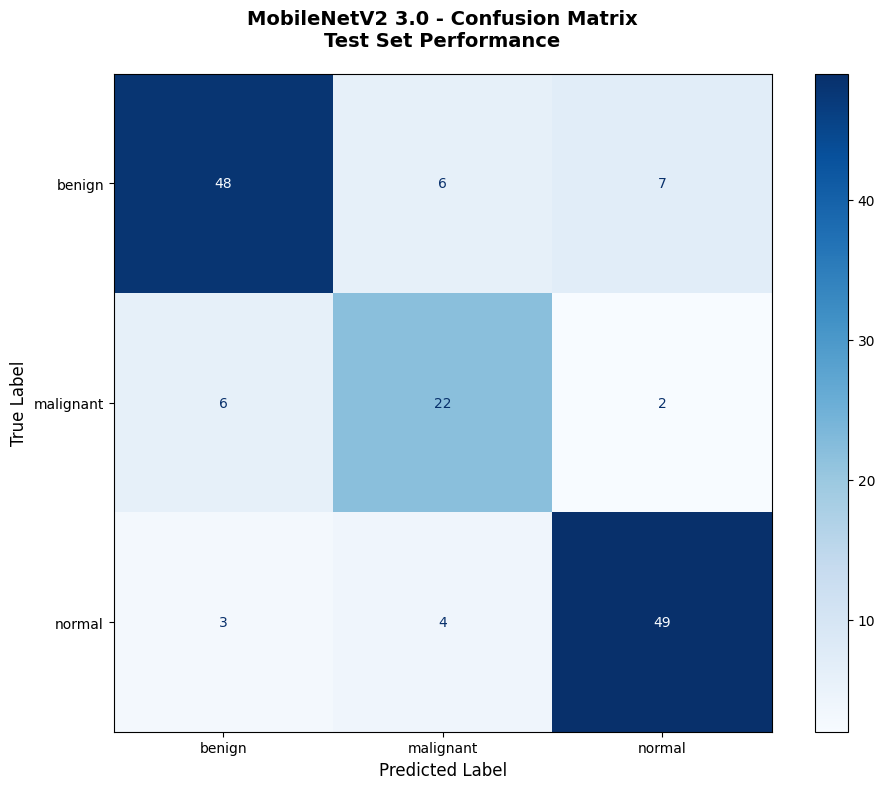

In [57]:
(
    y_pred_final_mobilenet,
    final_accuracy,
    final_loss,
    report_final_mobilenet,
    cm_final_mobilenet,
    ) = evaluate_keras_classifier(
    final_model,
    X_test_rgb_final224,
    y_test,
    label_encoder,
    title='MobileNetV2 3.0',
    )

MobileNetV2 3.0 reached our highest performance peak, at 80.95% accuracy. This version performs better mainly because of stronger Gaussian Noise and L2 penalty, making the model ignore random ultrasound grain and focus on real lesion patterns. It also uses harder augmentation and higher-resolution inputs, which improves generalization, and now stands as the best at finding normal cases among all of our models. One of the most noticeable results is the reduction of false normal cases, which went down from 15 in the previous model to only 9 in this model.

## ResNet50



Building upon our previous models, we transitioned to ResNet50 to explore whether a significantly deeper and more complex architecture could solve the challenges our earlier versions faced. ResNet50 uses a system called 'skip connections' that allows clearer inputs to be passed on, and thus prevents the model from getting confused as it learns. By using this extra power, we aim to see if the model can catch those masses that the smaller models had difficulty in classifying. 

### Build ResNet50 Model (Using Original 128x128 Inputs)
This step initializes the model architecture and prepares it for compilation and training.

In [58]:

tf.keras.backend.clear_session()
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

_, basic_resnet_model = build_resnet50_basic(
    input_shape=X_train_rgb.shape[1:],
    num_classes=len(label_encoder.classes_),
    )

### Compile ResNet50 Model
This step defines the optimizer, loss, and metrics used consistently for model learning.

In [59]:
basic_resnet_model.compile(optimizer=Adam(learning_rate=0.0001),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

### Strategies for ResNet50

In this model, we will be using EarlyStopping to prevent the model from overfitting.

In [60]:
basic_resnet_early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [61]:
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

### Train Basic ResNet50 Model
This step fits the model with callbacks and validation monitoring to improve generalization.

In [62]:
basic_resnet_history = basic_resnet_model.fit(
    X_train_rgb,
    y_train_augmented,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=[basic_resnet_early_stopping],
    verbose=1
)

print(f"\nResNet50 model training completed.")

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 349ms/step - accuracy: 0.3128 - loss: 1.1729 - val_accuracy: 0.3767 - val_loss: 1.1091
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 350ms/step - accuracy: 0.3128 - loss: 1.1156 - val_accuracy: 0.3767 - val_loss: 1.0923
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 309ms/step - accuracy: 0.3184 - loss: 1.1004 - val_accuracy: 0.4452 - val_loss: 1.0910
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 390ms/step - accuracy: 0.3504 - loss: 1.0966 - val_accuracy: 0.3904 - val_loss: 1.0915
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 305ms/step - accuracy: 0.3426 - loss: 1.0951 - val_accuracy: 0.4041 - val_loss: 1.0914
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 316ms/step - accuracy: 0.3468 - loss: 1.0938 - val_accuracy: 0.4041 - val_loss: 1.0908
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 396ms/step - accuracy: 0.3553 - loss: 1.0926 - val_accuracy: 0.4110 - val_loss: 1.0898
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 305ms/step - accuracy: 0.3617 - loss: 1.0914 - val_accu

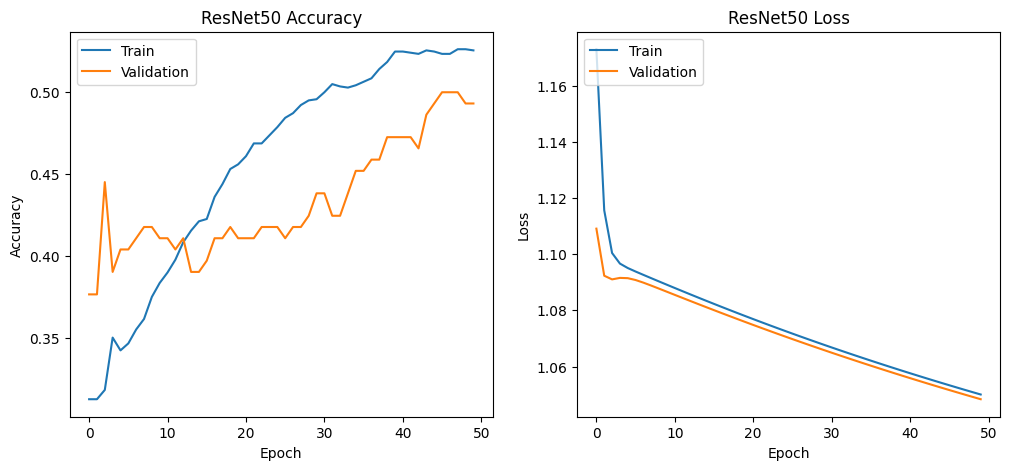

In [63]:
plot_training_history(basic_resnet_history, 'ResNet50')


### Evaluate ResNet50

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 618ms/step

TEST SET EVALUATION - ResNet50
Test Loss: 1.0480
Test Accuracy: 50.34%

Per-class Metrics (Precision / Recall / F1-score / Support):
              precision    recall  f1-score   support

      benign     0.5309    0.7049    0.6056        61
   malignant     0.3696    0.5667    0.4474        30
      normal     0.7000    0.2500    0.3684        56

    accuracy                         0.5034       147
   macro avg     0.5335    0.5072    0.4738       147
weighted avg     0.5624    0.5034    0.4830       147



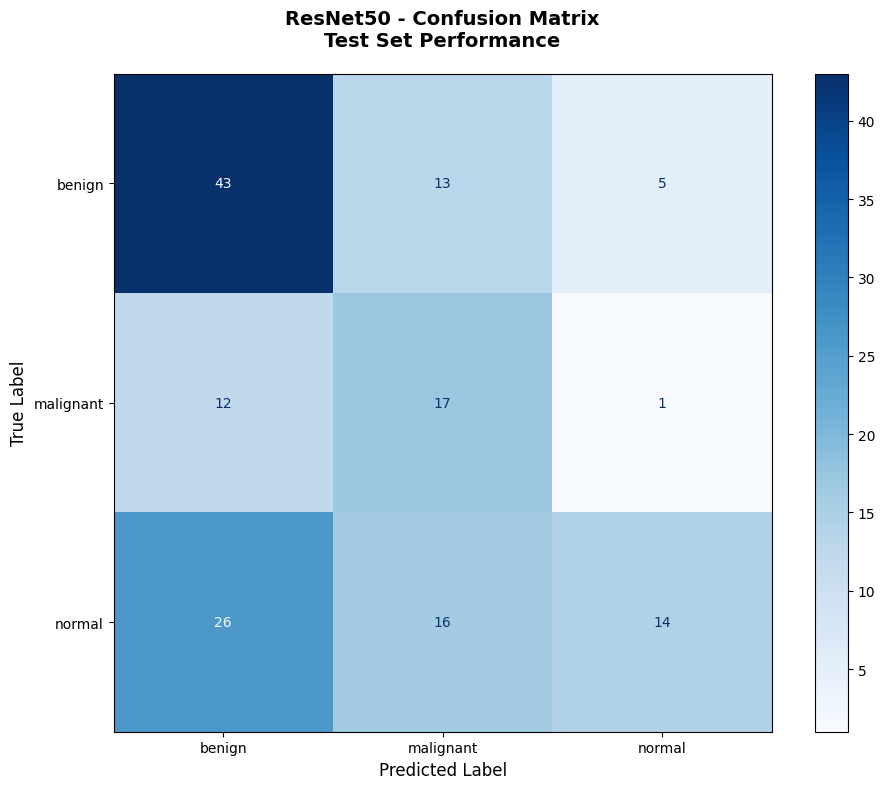

In [64]:
y_pred_resnet, resnet_accuracy, resnet_loss, report_resnet, cm_resnet = evaluate_keras_classifier(
    basic_resnet_model,
    X_test_rgb,
    y_test,
    label_encoder,
    title='ResNet50',
    )

Our ResNet50 implementation yielded a baseline accuracy of 50.34%, significantly underperforming in comparison to our previous models. The loss curves suggest that the model is in a state of underfitting, where it fails to capture the features of our images. While ResNet50 is a popular choice for many image classification tasks due to its high architectural capacity, our results show that with only a small dataset, the model's depth is a disadvantage for this specific ultrasound classification task

## ResNet50 2.0



To test ResNet50 more on our dataset, we created a fine-tuned version that uses the same 128x128 RGB input. This Version 2.0 follows the same training strategy used in the MobileNetV2 2.0 setup: two-phase training, class-weighted learning, and adaptive callbacks for stability. In Phase 1, the classifier head is trained while the backbone remains frozen to preserve useful pretrained features. In Phase 2, the upper backbone layers are unfrozen for fine-tuning, combined with a lower learning rate. BatchNormalization layers also stay frozen to reduce training instability on limited medical data. This setup allows us to evaluate whether ResNet50 (the previous version) underperformed because of architecture mismatch or because it needed stronger optimization controls. 

In [65]:
tf.keras.backend.clear_session()
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

### Build ResNet50 2.0
This step initializes the model architecture and prepares it for compilation and training.

In [66]:
resnet_v2_base, resnet_v2_model = build_resnet50_basic(
    input_shape=X_train_rgb.shape[1:],
    num_classes=len(label_encoder.classes_),
    )

### Compile ResNet50 2.0
This step defines the optimizer, loss, and metrics used consistently for model learning.

In [67]:
# Phase 1 compile: train classifier head with frozen backbone
resnet_v2_model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )

### Strategies for ResNet50 2.0

Define class weights and callbacks for the two-phase ResNet run.

In [68]:
resnet_v2_class_weight_dict = {
    0: 1.0,  # Benign
    1: 1.25,  # Malignant
    2: 1.0,  # Normal
    }

resnet_v2_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    min_delta=0.0015,
    restore_best_weights=True,
    start_from_epoch=6,
    )

resnet_v2_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    cooldown=1,
    min_lr=1e-6,
    verbose=1,
    )

In [69]:
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

Train phase 1 with frozen backbone using validation monitoring.

### Train ResNet50 2.0
This step fits the model with callbacks and validation monitoring to improve generalization.

In [70]:

resnet_v2_history = resnet_v2_model.fit(
    X_train_rgb,
    y_train_augmented,
    epochs=60,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=[resnet_v2_early_stopping, resnet_v2_reduce_lr],
    class_weight=resnet_v2_class_weight_dict,
    shuffle=True,
    verbose=1,
    )

Epoch 1/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 340ms/step - accuracy: 0.3128 - loss: 1.2805 - val_accuracy: 0.3767 - val_loss: 1.1181 - learning_rate: 1.0000e-04
Epoch 2/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 309ms/step - accuracy: 0.3156 - loss: 1.2032 - val_accuracy: 0.2192 - val_loss: 1.1168 - learning_rate: 1.0000e-04
Epoch 3/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 334ms/step - accuracy: 0.3454 - loss: 1.1846 - val_accuracy: 0.2055 - val_loss: 1.1247 - learning_rate: 1.0000e-04
Epoch 4/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.3466 - loss: 1.1806
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 309ms/step - accuracy: 0.3404 - loss: 1.1806 - val_accuracy: 0.2055 - val_loss: 1.1275 - learning_rate: 1.0000e-04
Epoch 5/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 545ms/step - accuracy: 0.3404 - loss: 1.1785 - val_accuracy: 0.2055 - val_loss: 1.1272 - learning_rate: 5.0000e-05
Epoch 6/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 

In [71]:
# Phase 2: fine-tune upper backbone layers
for layer in resnet_v2_base.layers[:-20]:
    layer.trainable = False
for layer in resnet_v2_base.layers[-20:]:
    layer.trainable = True
for layer in resnet_v2_base.layers:
    if layer.__class__.__name__ == 'BatchNormalization':
        layer.trainable = False

In [72]:
resnet_v2_model.compile(
    optimizer=Adam(learning_rate=1e-5, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )

In [73]:
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

Run phase 2 fine-tuning with lower learning rate after unfreezing top layers.

In [74]:
resnet_finetune_history = resnet_v2_model.fit(
    X_train_rgb,
    y_train_augmented,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=[resnet_v2_early_stopping, resnet_v2_reduce_lr],
    class_weight=resnet_v2_class_weight_dict,
    shuffle=True,
    verbose=1,
    )

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 386ms/step - accuracy: 0.3475 - loss: 1.1666 - val_accuracy: 0.3151 - val_loss: 1.0914 - learning_rate: 1.0000e-05
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 351ms/step - accuracy: 0.4355 - loss: 1.1298 - val_accuracy: 0.4932 - val_loss: 1.0356 - learning_rate: 1.0000e-05
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 352ms/step - accuracy: 0.4894 - loss: 1.0771 - val_accuracy: 0.5137 - val_loss: 0.9844 - learning_rate: 1.0000e-05
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 352ms/step - accuracy: 0.5333 - loss: 1.0345 - val_accuracy: 0.5342 - val_loss: 0.9704 - learning_rate: 1.0000e-05
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 353ms/step - accuracy: 0.5482 - loss: 1.0013 - val_accuracy: 0.5822 - val_loss: 0.9705 - learning_rate: 1.0000e-05
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 354ms/step - accuracy: 0.5617 - loss: 0.9822 - val_accuracy: 0.5616 - val_loss: 0.9429 - learning_rate: 1.0000e-05
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 363ms/step - acc

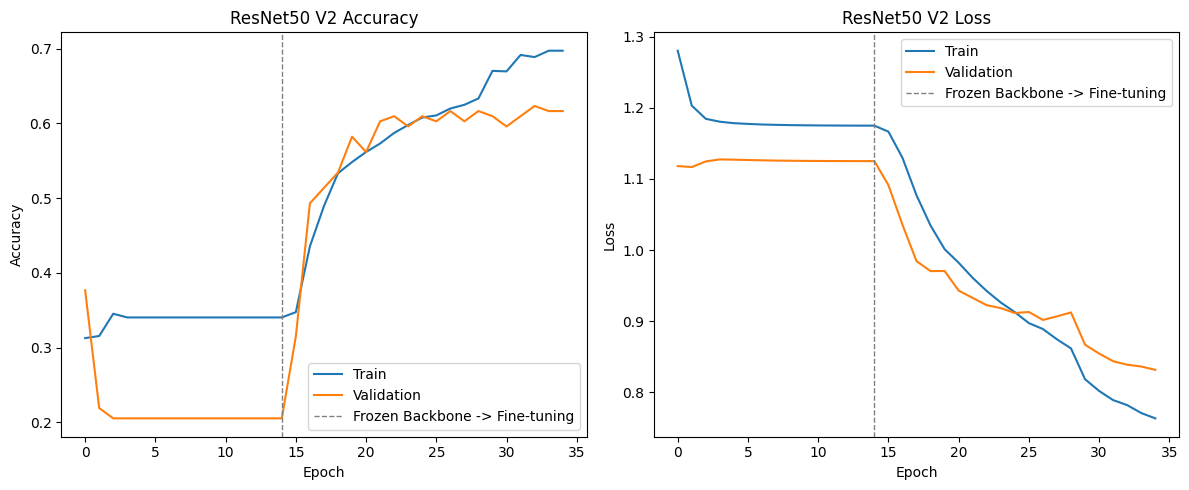

In [75]:
plot_two_phase_training_history(
    resnet_v2_history,
    resnet_finetune_history,
    title='ResNet50 V2',
    phase1_label='Frozen Backbone',
    phase2_label='Fine-tuning',
)

From the graphs, the accuracy and loss for both training and validation significantly improved when moving from the first to the second phase. This says a lot about how the model was able to adapt its weights to the specific features found in the breast ultrasound images when its backbone layers were unfrozen.

### Test Set Evaluation
This section reports final performance on unseen test data using the same evaluation process across models.

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 493ms/step

TEST SET EVALUATION - ResNet50 V2
Test Loss: 0.8287
Test Accuracy: 63.95%

Per-class Metrics (Precision / Recall / F1-score / Support):
              precision    recall  f1-score   support

      benign     0.7021    0.5410    0.6111        61
   malignant     0.5938    0.6333    0.6129        30
      normal     0.6176    0.7500    0.6774        56

    accuracy                         0.6395       147
   macro avg     0.6378    0.6414    0.6338       147
weighted avg     0.6478    0.6395    0.6367       147



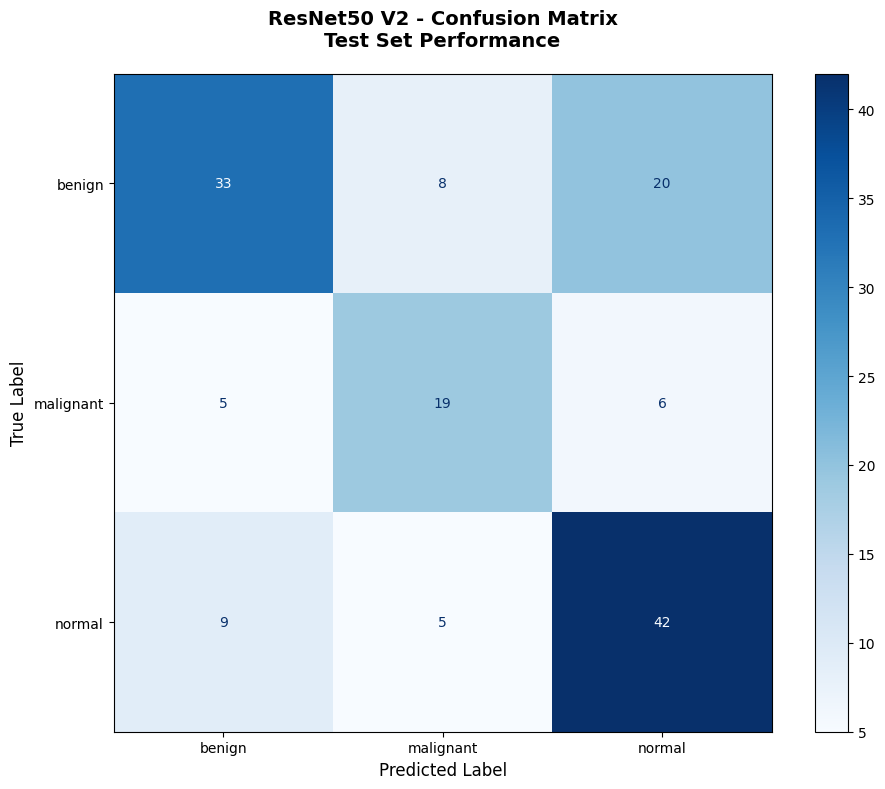

In [76]:
(
    y_pred_resnet_finetuned,
    resnet_finetuned_accuracy,
    resnet_finetuned_loss,
    report_resnet_finetuned,
    cm_resnet_finetuned,
    ) = evaluate_keras_classifier(
    resnet_v2_model,
    X_test_rgb,
    y_test,
    label_encoder,
    title='ResNet50 V2',
    )

ResNet50 2.0 achieved 63.95% test accuracy, improving substantially over the basic ResNet50 baseline (50.34%). With two-phase fine-tuning, class weighting, and frozen Batch Normalization layers during phase 2, the model trained more stably and improved its ability to predict cases. However, despite these gains, performance still lagged behind the MobileNetV2 variants, and even the classical Random Forest model, suggesting that ResNet50 remains relatively over-complex for this dataset size.

---

# Evaluation and Error Analysis

## Comparative Analysis of Models

| Model | Test Accuracy | Malignant Recall | Malignant Precision |
|---|---:|---:|---:|
| Random Forest | **66.67%** | **66.67%** | **52.63%** |
| MobileNetV2 | **71.43%** | **76.67%** | **62.16%** |
| MobileNetV2 2.0 | **76.19%** | **73.33%** | **62.86%** |
| MobileNetV2 3.0 | **80.95%** | **73.33%** | **68.75%** |
| ResNet50 | **50.34%** | **56.67%** | **36.96%** |
| ResNet50 2.0 | **63.95%** | **63.33%** | **59.38%** |

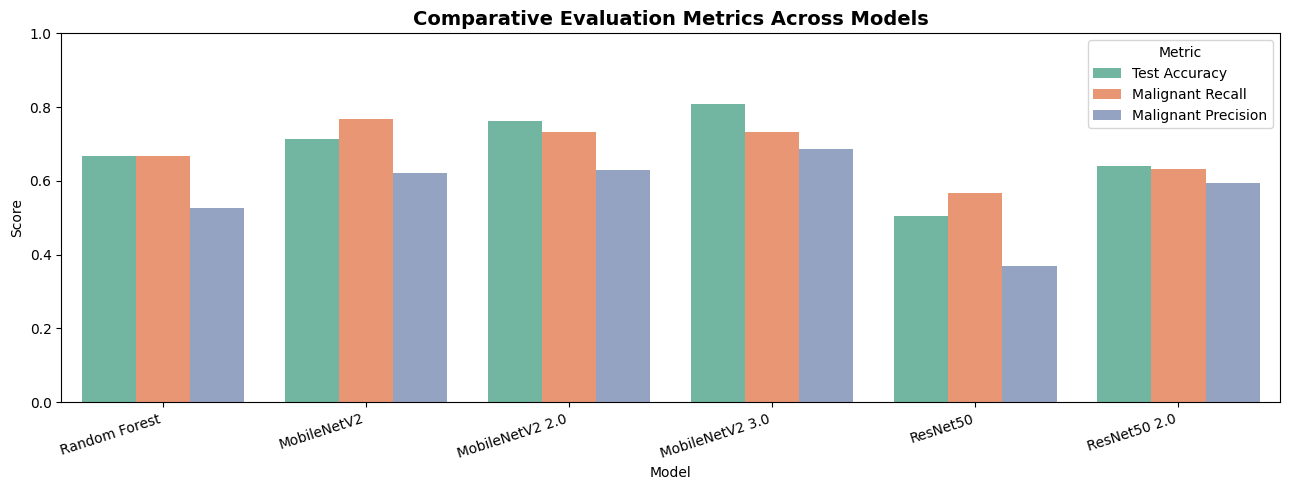

In [77]:
plot_comparative_metrics_section()

Among all the models we have trained, the model that stands out in terms of accuracy is MobileNetV2 3.0, which we fine-tuned by integrating L2 regularization and Gaussian Noise, on top of heavily augmenting our training images. Following MobileNetV2 3.0 is MobileNetV2 2.0 with 76.19% accuracy, where we introduced early stopping and the reduction of learning rate. This was followed by the base MobileNetV2 and Random Forest, leaving both ResNet50 versions as the worst performing models.

The ResNet50 models' poor performances could be attributed to the mismatch between its architecture and our dataset. Its high parameter count and 50-layer depth led to poor convergence on our 1,400 grayscale ultrasound images. Its heavyweight structure was too over-engineered to effectively extract the subtle, low-resolution clinical features required for accurate classification.

In terms of recall in the malignant class, the model that performed best was the base MobileNetV2. This version did not have dropouts, gaussian noise, and even L2 regularization, leaving the model loose and may have prompted it to associate hints of shadow with "Malignant." This also used a flat learning rate of 0.0001 for all epochs, which can push the weights into a state of bias towards the most complex features.

**With the variation in test accuracy and metrics related to malignancy, we see MobileNetV2 3.0 as the model that stands out amongst all due as it has attained the highest accuracy (80.95%) and malignant precision, and lagged only by a small amount behind the base MobileNetV2 in terms of malignant recall.**

## Strategies and Their Impact

### Data-Centric Strategies

In both MobileNetV2 2.0 and 3.0, we introduced weighted loss functions, specifically assigning the malignant class a weight of 1.25. In MobileNetV2 3.0, we transitioned to a more aggressive augmentation strategy, applying 2x augmentation for benign and normal classes and 4x augmentation for the malignant class to address the data scarcity of the latter. Simultaneously, we upscaled the input resolution from 128×128 to 224×224.

While these strategies were unable to increase the recall for the malignant class, we were effectively able to increase the overall accuracy by 4.76% to 9.52% in comparison to the baseline model that did not possess the mentioned characteristics. Moreover, we successfully reduced the number of high-risk "false normal" cases from 16 to 9.

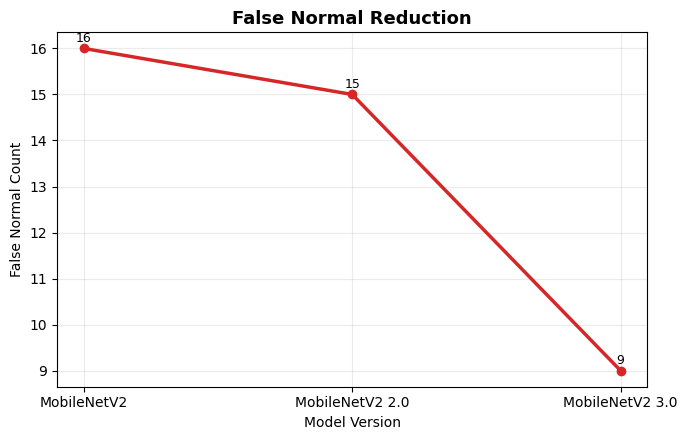

In [78]:
evaluation_utils.plot_false_normal_reduction(
    versions=["MobileNetV2", "MobileNetV2 2.0", "MobileNetV2 3.0"],
    false_normals=[16, 15, 9],
)

### Model-Centric Strategies

In MobileNetV2 2.0 and 3.0, we implemented a Two-Phase Transfer Learning strategy to stabilize the training of the 2.2M-parameter backbone. By initially freezing the pretrained ImageNet layers and only training the custom classifier head, we prevented "catastrophic forgetting" of foundational edge-detection features. During the second phase, we unfroze the last 20 to 30 layers and applied a conservative learning rate, allowing the model to adapt to the specific textures of ultrasound imagery without destabilizing the weight distributions.

To combat the inherent noise in ultrasound "speckle" patterns, we introduced Gaussian Noise layers and L2 regularization in the final classifier. Increasing the noise factor from 0.03 in Version 2.0 to 0.1 in Version 3.0 acted as a powerful regularizer, forcing the model to ignore pixel-level artifacts and focus on features like lesion shape and boundary density. While these constraints made the model more "conservative" in its predictions, contributing to the slight drop in recall, they were essential in achieving our peak overall accuracy of 80.95% and ensuring the model generalized across the dataset rather than simply memorizing training noise.

In our analysis of the ResNet50 models, we identified that the primary driver of poor performance (50.34%) was an architectural mismatch with our 1,400-image dataset. To mitigate this in ResNet50 2.0, we specifically froze the Batch Normalization (BN) layers during the fine-tuning phase. This prevented the noisy statistics of our small batch size (32) from overwhelming the model's internal weights. While this optimization improved ResNet's accuracy to 63.95%, the model remained fundamentally over-engineered for the task.

## Error Analysis and Failure Detection

### Random Forest
The Random Forest baseline, despite achieving 66.67% accuracy, suffered from a fundamental lack of spatial awareness. Because this classical model treats each of the 16,384 pixels as an independent feature rather than part of a cohesive structure, it cannot "see" a tumor’s shape or boundary—only its raw brightness values. Its primary failure was high inter-class confusion, where it frequently misclassified benign to fall as any of the other two classes.

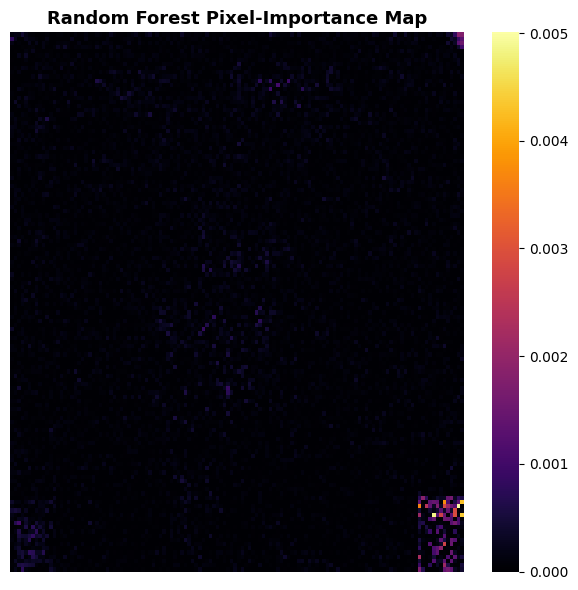

In [79]:
evaluation_utils.plot_random_forest_pixel_importance_map(globals())

Based on the pixel-importance map, we can see that the model could barely focus on the center part of the image. However, it seems to be giving a high important to the pixels located at the lower right. This seems to have come from the BUS-UCLM dataset where there is a gray guide of the location within the breast that the ultrasound image shows. And this is actually irrelevant to the classification, which explains why the model had difficulties in predicting correctly.

Benign total test samples: 61
Benign correctly classified: 31
Benign misclassified: 30


c:\Users\marxa\OneDrive\Documents\GitHub\CSC713M-Breast-Cancer-Classification\evaluation_utils.py:392: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mis_labels, y=mis_counts, palette="Set2")


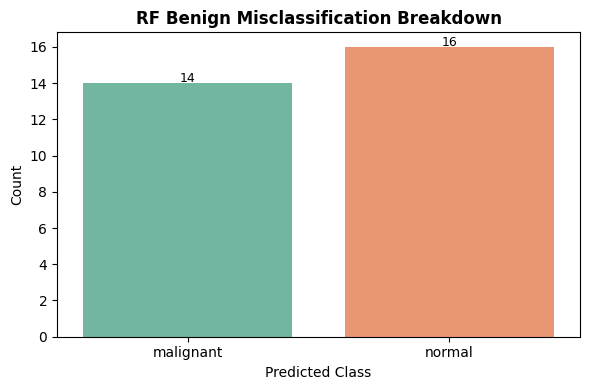

In [80]:
evaluation_utils.plot_random_forest_benign_misclassification_breakdown(globals())

Out of 61 benign cases, only 31 were correctly predicted. This means that almost half of the benign cases was incorrectly predicted by the RF model.

### ResNet50

In contrast, the ResNet50 family represented an architectural mismatch for our 1,400-image dataset. As a "heavyweight" model with 25 million parameters, the base version stalled at 50.34% accuracy, failing to converge because the signal in our grayscale, 128×128 images was too subtle to navigate 50 layers of abstraction. We identified "Feature Smearing" as the primary culprit: as the image passes through dozens of downsampling layers, the critical edges of a tumor are blurred into generic representations. Even in the second version, where we stabilized training by freezing Batch Normalization layers to reach 63.95%, the model remained too over-engineered to generalize medical textures effectively.

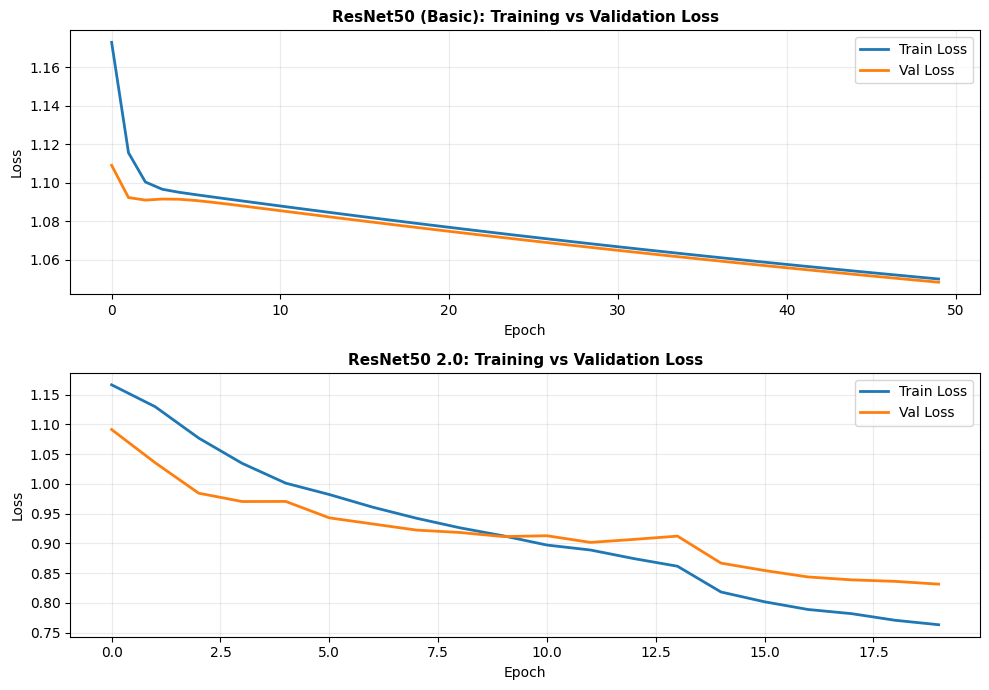

In [81]:
evaluation_utils.plot_training_loss_section(
    globals(),
    model_names=["ResNet50 (Basic)", "ResNet50 2.0"],
)

### MobileNetV2

Without the discipline provided by Gaussian Noise or L2 regularization, the basic MobileNetV2 model overfits to the specific malignant patterns in the training set, leading to the highest malignant recall (76.67%) across all tests. However, this came at the cost of low precision; the model frequently triggered false normals, as it lacked the regularization needed to distinguish between actual malignant structural irregularities and simple ultrasound artifacts like shadowing or speckle grain.

### MobileNetV2 2.0

The primary weakness of MobileNetV2 2.0 was its low input resolution (128×128), which acted as a visual bottleneck that "smeared" critical diagnostic details. While we improved the model's internal logic through two-phase fine-tuning and noise regularization, the limited pixel density meant that the jagged, irregular borders typical of malignant tumors were downsampled into smooth, benign-looking edges. This lack of granular detail prevented the model from distinguishing subtle textures, leading to 15 "False Normal" errors where cancerous lesions were misidentified as healthy tissue. Essentially, the model was starved with information, proving that high-level reasoning cannot compensate for a fundamental loss of visual evidence.

### MobileNetV2 3.0

Finally, the MobileNetV2 3.0 model reached the peak of 80.95% accuracy. By shifting to a 224×224 resolution and a 0.1 Gaussian Noise factor, we forced the model to ignore pixel-level noise and focus purely on the geometric shape and boundary. The weakness of MobileNetV2 3.0 was mainly isoechoic mimicry, having a malignant tumor’s brightness and texture perfectly blend into the surrounding healthy tissue. Even with the move to 224×224 resolution, these "invisible" borders made it mathematically difficult for the model to define a clear lesion margin. However, by providing more than 3x pixel data than previous versions, the model gained the "visual depth" needed to detect subtle edge irregularities that were previously hidden. This increased detail was the key factor in reaching our highest overall accuracy of 80.95% and successfully reducing the most dangerous clinical errors, False Normals, from 16 down to 9.


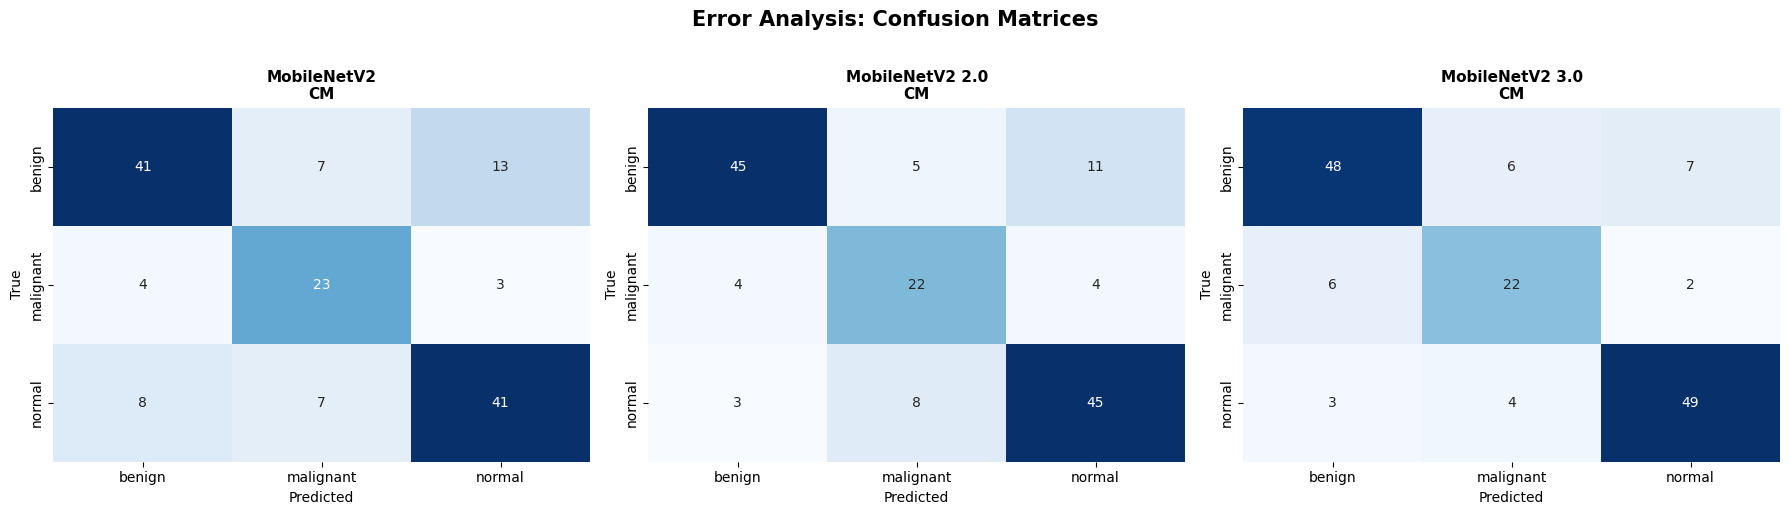

In [82]:
evaluation_utils.plot_confusion_matrices_section(
    globals(),
    normalize=False,
    model_names=["MobileNetV2", "MobileNetV2 2.0", "MobileNetV2 3.0"],
)

## Machine Learning Perspective Evaluation

### Model Complexity vs. Data Volume

The most significant finding from an ML standpoint was the architectural mismatch seen in the ResNet50 models. With 25 million parameters, ResNet was mathematically "over-engineered" for a dataset of 1,400 images. This led to an optimization stall where the model could not find a stable global minimum, resulting in a flat accuracy of ~50%. In contrast, MobileNetV2, with only 2.2 million parameters, proved that a lesser-weighing architecture is more effective for small-scale medical imaging tasks, as it balances depth with a manageable number of trainable weights.

### Feature Extraction and Resolution

Evaluation of the MobileNetV2 2.0 vs. 3.0 models revealed a clear resolution bottleneck. From an ML perspective, the move from 128×128 to 224×224 resolution increased the input feature space by triple times over. This allowed the convolutional filters to capture "high-frequency" spatial features—such as the sharp, jagged edges of malignant tumors—that were mathematically smoothed out at lower resolutions. The reduction of False Normals from 16 to 9 proves that the model's ability to generalize was physically limited by the input data density.

### The Role of Regularization

The introduction of Gaussian Noise served as a critical filter. Ultrasound images are naturally prone to speckle noise (graininess), which a CNN can easily mistake for actual tissue texture. By injecting artificial noise during training, we forced the model to ignore these pixel-level artifacts and prioritize features such as the lesion’s overall shape and boundary density. This shifted the model from memorizing specific image noise to learning the geometric properties of breast cancer.

To complement this, we applied L2 Regularization (Weight Decay) to the final classification layers. While Gaussian Noise addressed the quality of the input data, L2 Regularization controlled the model’s internal complexity by penalizing excessively large weights. This prevented the model from becoming over-reliant on any single "pixel feature" and instead forced it to distribute its learning across multiple diagnostic indicators. Together, these strategies were essential in managing the Precision-Recall trade-off; although they made the model more "conservative" in its predictions, they ensured that the resulting accuracy of 80.95% was based on stable clinical features rather than random imaging artifacts.

### Optimization and Stability

The success of the Two-Phase Transfer Learning strategy demonstrated the importance of weight stabilization. By freezing the backbone initially, we allowed the classifier head to align with the ImageNet features. The subsequent fine-tuning at an ultra-low learning rate (5x10<sup>−6</sup>) in MobileNetV2 3.0 allowed for "surgical" updates to the deep layers. This prevented catastrophic forgetting, ensuring the model retained its general edge-detection capabilities while adapting to the unique grayscale textures of ultrasound imagery.

### Addressing Class Imbalance

A critical factor in shaping model behavior for this task is the inherent class imbalance, specifically the lower frequency of malignant samples compared to benign and normal cases. To ensure the models remain sensitive to malignancy despite this distribution, the training framework incorporates data augmentation and class weighting. These strategies were specifically designed to optimize the recall for the malignant class within the MobileNetV2 variants. By penalizing the misclassification of minority samples,  we effectively balanced the model's predictive performance.


CLASS COUNTS BY STAGE
                    benign  malignant  normal
No Augmentation        489        240     441
Base Augmentation      489        480     441
Final Augmentation    1467       1200    1323


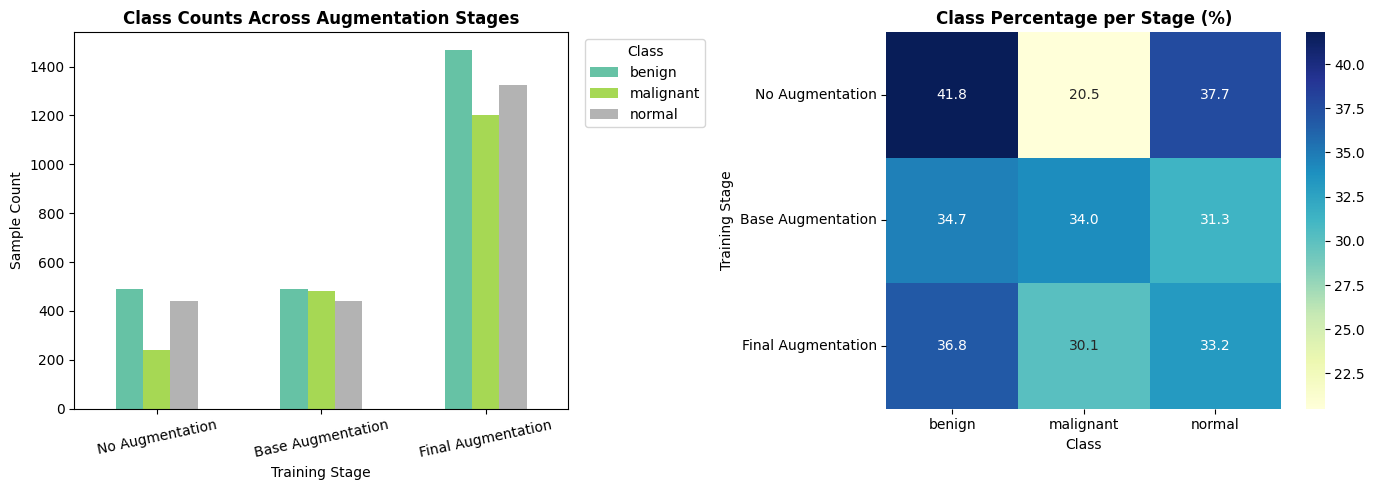

In [83]:
evaluation_utils.plot_class_imbalance_progress(globals())

## Clinical Perspective Evaluation

### False Normal Reduction

In a clinical diagnostic setting, the most critical failure is a False Normal (a malignant/benign tumor misidentified as healthy tissue), as it leads to delayed intervention and increased risk to patient life. Our evaluation focused on mitigating this high-stakes error by implementing a 1.25 malignant class weight, which biased the model toward caution. This deliberate clinical choice, combined with high-resolution scaling, successfully reduced the count of "missed" cancers from 16 to 9 cases. While this resulted in a slight drop in overall recall, the trade-off was a more stable and "clinically safer" model that prioritized life-saving detection over simple statistical accuracy.

### Generalization Across Different Sources

For a Computer-Aided Diagnosis (CAD) tool to be useful in a real hospital, it must work across different ultrasound machines and patient populations. By evaluating the model on a merged dataset (BUSI and BUS-UCLM), we proved its ability to generalize across different "grain" patterns and imaging hardware. Maintaining an 80.95% accuracy across these diverse sources suggests the model is learning universal biological features of breast cancer. This makes it a viable candidate for a screening assistant that can provide a "second opinion" in various clinical environments.

# Suggestions for Future Improvements

### Malignant Class Data

In our merged dataset, malignant cancer images only comprised approximately 20.5%, which we made up for by augmenting. While augmenting was a good approach in increasing accuracy, we believe that having enough malignant images to start with would yield better results as the model will learn from actual, real-life medical imagery rather than from four modified copies of each original image.

### Input Resolution

In most of our models, we used images of 128x128 resolution. While this gave us decent accuracy percentages, increasing the resolution to 224x224 massively helped us attain a higher accuracy of 80.95% in our MobileNetV2 3.0 model. We intended to apply this higher resolution to our ResNet50 iterations to see if its deeper architecture could further capitalize on the added detail. However, due to computational constraints and the significant increase in training overhead, we were unable to finalize these versions within the current project scope. We highly recommend exploring higher-resolution inputs in future work to determine if providing more "visual data" allows ResNet50 to finally outperform the more lightweight MobileNetV2.

### Unseen Test Data
Since our training dataset is a combination of two datasets, we suggest exploring external validation by using an entirely unseen dataset as test dataset. Evaluating on a different dataset could reveal if the models presented here, particularly the MobileNetV2 3.0, could generalize to ultrasound images coming from different clinics.

# Conclusion




PER-MODEL METRICS SUMMARY
              Model Accuracy Macro Precision Macro Recall Macro F1 Malignant Precision Malignant Recall Malignant F1
      Random Forest   0.6667          0.6579       0.6714   0.6514              0.5263           0.6667       0.5882
MobileNetV2 (Basic)   0.7143          0.7048       0.7236   0.7105              0.6216           0.7667       0.6866
    MobileNetV2 2.0   0.7619          0.7480       0.7582   0.7497              0.6286           0.7333       0.6769
    MobileNetV2 3.0   0.8095          0.7915       0.7984   0.7943              0.6875           0.7333       0.7097
   ResNet50 (Basic)   0.5034          0.5335       0.5072   0.4738              0.3696           0.5667       0.4474
       ResNet50 2.0   0.6395          0.6378       0.6414   0.6338              0.5938           0.6333       0.6129


c:\Users\marxa\OneDrive\Documents\GitHub\CSC713M-Breast-Cancer-Classification\evaluation_utils.py:904: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acc_models, y=acc_values, palette="crest")


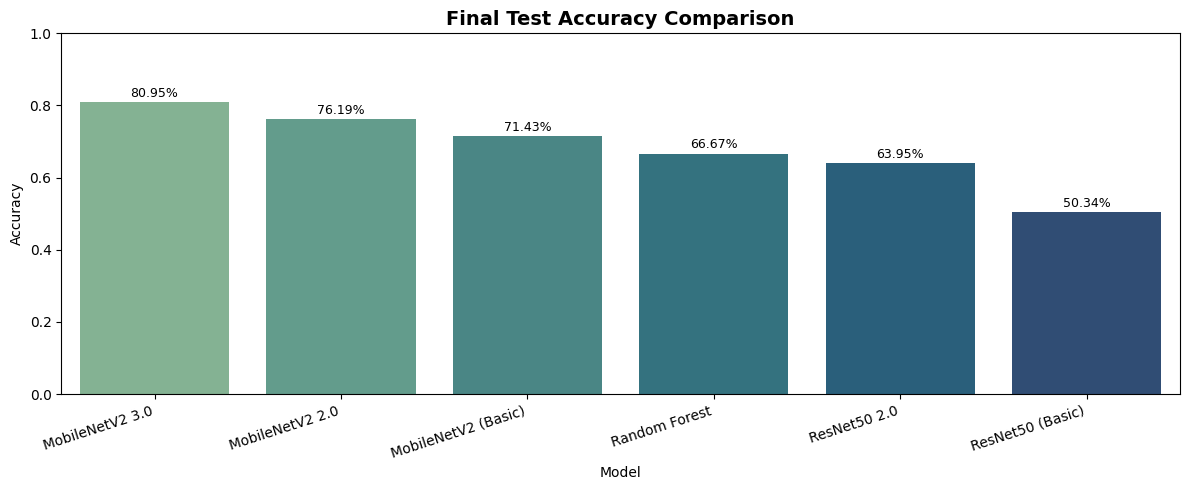

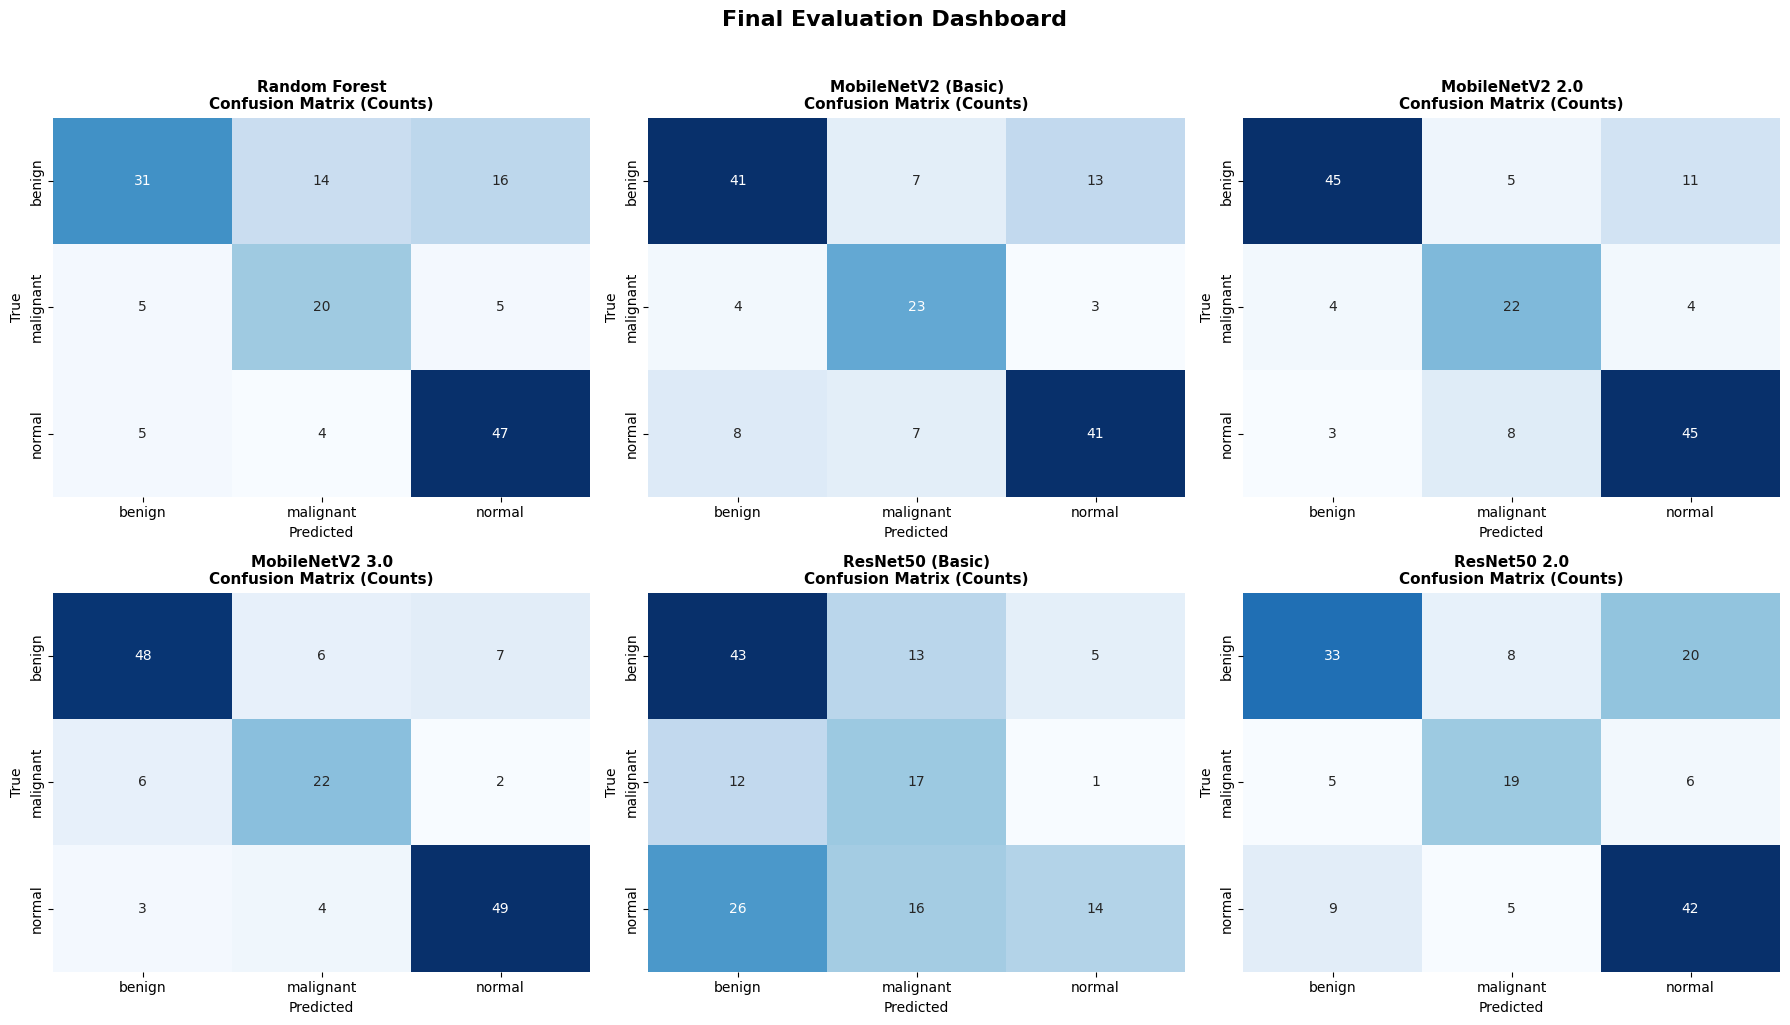

In [84]:
plot_final_evaluation_dashboard_section(globals())

The evaluation of these models across the BUSI and BUS-UCLM datasets demonstrates that effective medical image classification depends on a balance between architectural efficiency and data-centric regularization.

Our evaluation confirms that "heavyweight" models like ResNet50 (25M parameters) are mathematically unsuitable for a dataset of 1,400 images, as their complexity leads to optimization stalls and a failure to converge (50.34%). In contrast, the MobileNetV2 family proved that a "thrifty" architecture is more capable of learning stable features from limited medical data. 

From a clinical perspective, the evaluation focused on patient safety. By implementing a 1.25 malignant class weight and 0.1 Gaussian Noise, we successfully moved the model to a disciplined diagnostic tool. This strategic shift allowed us to reduce the most dangerous clinical error, mistaking malignant/benign classes for normal. While isoechoic mimicry (tumors that blend into surrounding tissue) remains an inherent limitation, the final model’s peak accuracy of 80.95% proves it can reliably distinguish between benign and malignant pathologies across different breast cancer ultrasound datasets.

**Ultimately, the evaluation reveals that MobileNetV2 3.0 is the superior configuration.** By combining two-phase fine-tuning with aggressive regularization, this model successfully ignored imaging artifacts and focused strictly on the morphological features required for accurate, safe, and reliable breast cancer screening.

# Declaration of Generative AI Use

Generative Artificial Intelligence was used in this notebook for the purpose of formatting summaries and visualizations, such as generating confusion matrices, accuracy and loss curves, and pixel-importance map. The owners of this notebook have thoroughly checked the generated content for appropriateness.

---

 Created by **TWIN FAIRY TACTICIANS**
- Aguarin, Trish Ann Danielle C.
- Cabato, Marxandrea Diane G.